# 👁️ Eye-Tracking Analysis Pipeline
### Physiological signals across guess types & anxiety groups

**File naming conventions expected:**
- Gaze files: `User 0_all_gaze.csv`, `User 1_all_gaze.csv`, … (one per participant)
- Click logs: `session_<name>_20260327_072843.csv` (participant ID read from `UserID` column inside)
- Labels: `participant_labels.csv` — columns: `participant_id`, `group`

**Pipeline:**
1. Mount Google Drive → set your folder paths in **Cell 0**
2. Auto-match gaze ↔ click files via `UserID` inside each click log
3. Parse click logs → per-question windows, guess types, confidence
4. Load & clean gaze data → pupil, blink, gaze signals
5. Compute per-participant gaze–click time offset from wall-clock headers
6. Slice gaze into question segments → extract features
7. Baseline-correct pupil per participant
8. Statistical tests (t-test / Mann-Whitney + FDR correction + Cohen's d)
9. Visualisations & CSV exports to `output_results/` in your Drive


## Cell 0 · Mount Google Drive & Set Paths

In [3]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# Point this to the base folder containing all your participant subfolders
DATA_ROOT = Path("/content/drive/MyDrive/SAD BTP/Gaze")

# Output — created automatically inside your Drive
OUTPUT_DIR = Path("/content/drive/MyDrive/eyetracking/gaze_analysis_output_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# We will store the labels file in the output directory to keep the data folder clean
LABELS_CSV = OUTPUT_DIR / "participant_labels.csv"

print("✅ Drive mounted")
print(f"   Searching in: {DATA_ROOT}")
print(f"   Labels file : {LABELS_CSV} (exists: {LABELS_CSV.exists()})")

Mounted at /content/drive
✅ Drive mounted
   Searching in: /content/drive/MyDrive/SAD BTP/Gaze
   Labels file : /content/drive/MyDrive/eyetracking/gaze_analysis_output_results/participant_labels.csv (exists: True)


In [4]:
# Run this to see all files in your data directory to find the correct labels file path
print("Listing files in DATA_ROOT:")
for path in DATA_ROOT.rglob('*'):
    if path.is_file():
        print(path.relative_to(DATA_ROOT))


Listing files in DATA_ROOT:
Aditya/aditya.prj
Akshitaa/akshitaa.prj
Bhavesh/Bhavesh.prj
Dhairya/dhairya.prj
Sravya/sravya.prj
Varsha/varsha.prj
Aditya/result/User 0_fixations.csv
Aditya/result/User 0_all_gaze.csv
Aditya/result/Data_Summary_export_04-02-26-17.32.16.csv
Aditya/result/video_export_04-06-26-15.04.13.avi
Aditya/result/session_Aditya Gautam_20260402_110932.csv
Aditya/user/0000-scrn.avi
Aditya/user/0000-face.avi
Aditya/user/0000-user.yml.gz
Aditya/user/backup/aditya.prj-26-04-02-16.27.48.prj.bak
Aditya/user/backup/aditya.prj-26-04-02-16.37.18.prj.bak
Aditya/user/backup/aditya.prj-26-04-02-17.32.09.prj.bak
Akshitaa/result/Data_Summary_export_04-01-26-13.42.36.csv
Akshitaa/result/User 0_fixations.csv
Akshitaa/result/User 0_all_gaze.csv
Akshitaa/result/video_export_04-06-26-16.12.24.avi
Akshitaa/result/session_Akshitaa Sahoo_20260401_073131.csv
Akshitaa/user/0000-scrn.avi
Akshitaa/user/0000-face.avi
Akshitaa/user/0000-user.yml.gz
Akshitaa/user/backup/akshitaa.prj-26-04-01-13.00.

## Cell 1 · Installs & Imports

In [5]:
import subprocess
subprocess.run(["pip", "install", "-q", "--upgrade", "statsmodels"], check=False)

import os, re, json, warnings
from itertools import combinations
from typing import Optional

import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({
    "figure.dpi"       : 120,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "font.family"      : "sans-serif",
})

GUESS_TYPES = ["strategic", "random", "intellectual", "not_guessed"]
PALETTE = {
    "strategic"   : "#2563EB",
    "random"      : "#DC2626",
    "intellectual": "#16A34A",
    "not_guessed" : "#9333EA",
    "anxiety"     : "#EA580C",
    "control"     : "#0891B2",
}
print("✅ Imports OK")


✅ Imports OK


## Cell 2 · File Discovery & Participant Matching

In [6]:
def discover_participants(root_dir: Path) -> list:
    """
    Recursively match gaze files to click logs in subdirectories.
    """
    # Use **/ to search recursively through all participant folders
    gaze_files = sorted(
        root_dir.glob("**/User *_all_gaze.csv"),
        key=lambda p: int(re.search(r"User (\d+)", p.name).group(1))
    )

    # Use **/ to find session logs anywhere under the root
    click_files = sorted(root_dir.glob("**/session_*.csv"))

    print(f"Found {len(gaze_files)} gaze file(s)")
    print(f"Found {len(click_files)} click log(s)")

    click_info = []
    for cf in click_files:
        try:
            with open(cf, "r", encoding="utf-8", errors="replace") as fh:
                first = fh.readline()
            sep = "\t" if "\t" in first else ","
            df  = pd.read_csv(cf, sep=sep, nrows=5)
            df.columns = df.columns.str.strip()
            pid = str(df["UserID"].iloc[0]) if "UserID" in df.columns else cf.stem
            click_info.append({"path": cf, "pid": pid})
        except Exception as e:
            print(f"  ⚠️  Could not read {cf.name}: {e}")

    participants = []
    for i, ci in enumerate(click_info):
        gaze_path = None
        for gf in gaze_files:
            try:
                with open(gf, "r", encoding="utf-8", errors="replace") as fh:
                    hdr_line = fh.readline()
                sep2 = "\t" if "\t" in hdr_line else ","
                hdr = pd.read_csv(gf, sep=sep2, nrows=2)
                hdr.columns = hdr.columns.str.strip()
                if "USER" in hdr.columns:
                    user_val = str(hdr["USER"].iloc[0]).strip()
                    if user_val == ci["pid"]:
                        gaze_path = gf
                        break
            except Exception:
                pass

        if gaze_path is None and i < len(gaze_files):
            gaze_path = gaze_files[i]

        status = "✅" if gaze_path else "⚠️ "
        print(f"  {status}  {ci['pid']}  ←→  {gaze_path.name if gaze_path else 'NO MATCH'}")

        if gaze_path:
            participants.append({"pid": ci["pid"], "click_path": ci["path"], "gaze_path": gaze_path})

    return participants

# Pass the single ROOT directory to the function
participants = discover_participants(DATA_ROOT)

Found 6 gaze file(s)
Found 6 click log(s)
  ✅  P3718de9d6a  ←→  User 0_all_gaze.csv
  ✅  P5512066f34  ←→  User 0_all_gaze.csv
  ✅  Pbdcb1b03d4  ←→  User 0_all_gaze.csv
  ✅  Pffea64f40a  ←→  User 0_all_gaze.csv
  ✅  P564190862f  ←→  User 0_all_gaze.csv
  ✅  Padff0cfc3f  ←→  User 0_all_gaze.csv


In [7]:
import pandas as pd

# Define who belongs to the anxiety group based on your input
anxiety_names = ["aditya", "bhavesh", "sravya"]

label_data = []
for p in participants:
    # We check if the name is part of the file path or ID
    name_found = False
    for name in anxiety_names:
        if name.lower() in str(p['click_path']).lower():
            label_data.append({"participant_id": p['pid'], "group": "anxiety"})
            name_found = True
            break

    if not name_found:
        label_data.append({"participant_id": p['pid'], "group": "control"})

# Create the DataFrame and save it to the OUTPUT directory as requested
labels_df = pd.DataFrame(label_data)
labels_df.to_csv(LABELS_CSV, index=False)

print(f"✅ Created {LABELS_CSV.name} in {OUTPUT_DIR} with {len(labels_df)} entries.")
display(labels_df)

✅ Created participant_labels.csv in /content/drive/MyDrive/eyetracking/gaze_analysis_output_results with 6 entries.


,participant_id,group
0,P3718de9d6a,anxiety
1,P5512066f34,control
2,Pbdcb1b03d4,anxiety
3,Pffea64f40a,control
4,P564190862f,anxiety
5,Padff0cfc3f,control


## Cell 3 · Timestamp Helpers

In [8]:
import pandas as pd
import re
from typing import Optional
from pathlib import Path

def extract_gaze_wall_start(gaze_filepath: str) -> Optional[pd.Timestamp]:
    """Read the wall-clock start of the gaze recording from the column header."""
    with open(gaze_filepath, "r", encoding="utf-8", errors="replace") as f:
        header = f.readline()
    m = re.search(r"TIME\((\d{4}/\d{2}/\d{2}\s+\d{2}:\d{2}:\d{2}(?:\.\d+)?)\)", header)
    if not m:
        print(f"  ⚠️  No TIME(...) found in header of {Path(gaze_filepath).name}")
        return None
    return pd.Timestamp(m.group(1).replace("/", "-"))

def parse_click_timestamp(ts: str) -> Optional[pd.Timestamp]:
    """Parse click log timestamps as naive local time."""
    ts = str(ts).strip()
    try:
        clean_ts = re.sub(r"\s+IST$", "", ts)
        return pd.Timestamp(clean_ts)
    except Exception as e:
        print(f"  ⚠️  Error parsing timestamp '{ts}': {e}")
        return None

def compute_gaze_offset(gaze_wall_start: Optional[pd.Timestamp],
                         session_wall_clock: Optional[pd.Timestamp],
                         pid: str = "") -> float:
    """Calculates offset by applying the mathematically correct timezones."""
    if gaze_wall_start is None or session_wall_clock is None:
        return 0.0

    try:
        # The math proves Gaze recorded in local time (IST) and Session recorded in UTC
        gaze_tz = gaze_wall_start.tz_localize("Asia/Kolkata")
        session_tz = session_wall_clock.tz_localize("UTC")
    except TypeError:
        gaze_tz = gaze_wall_start.tz_convert("Asia/Kolkata") if gaze_wall_start.tzinfo else gaze_wall_start.tz_localize("Asia/Kolkata")
        session_tz = session_wall_clock.tz_convert("UTC") if session_wall_clock.tzinfo else session_wall_clock.tz_localize("UTC")

    # Calculate absolute difference in seconds
    offset = (session_tz - gaze_tz).total_seconds()

    print(f"  [{pid}] Gaze start (IST)   : {gaze_tz}")
    print(f"  [{pid}] Session start (UTC): {session_tz} -> (IST: {session_tz.tz_convert('Asia/Kolkata')})")
    print(f"  [{pid}] Computed Offset    : {offset:.1f} s")

    return offset

print("✅ Corrected timezone alignment (Gaze=IST, Session=UTC)")

✅ Corrected timezone alignment (Gaze=IST, Session=UTC)


## Cell 4 · Click-Log Parser

In [9]:
def compute_actual_rt(df: pd.DataFrame, qn: int,
                      first_seen_elapsed: float,
                      last_submit_elapsed: float) -> float:
    """
    Actual time spent on question Qn using QChange visit windows.

    Naive approach (last_submit - first_seen) is wrong when participants
    mark a question, navigate away, and come back. The away-time gets
    counted as question time — inflating RT for revisited questions by
    hundreds of seconds (e.g. Q7: naive=1086s, actual=27s).

    Correct approach: reconstruct visit windows from QChange events.
      Visit START: Qfirstseen (first visit) OR QChange *to* this Qn (return)
      Visit END:   QChange *away from* this Qn
    Final window always closes at last_submit_elapsed.
    Total RT = sum of all visit durations.
    """
    if pd.isna(first_seen_elapsed) or pd.isna(last_submit_elapsed):
        return np.nan

    qchange = df[df["EventType"] == "QChange"].sort_values("TimeElapsed")

    arrivals = [first_seen_elapsed]
    for _, row in qchange.iterrows():
        if row["vf"].get("Qnto") == qn:
            t = float(row["TimeElapsed"])
            if first_seen_elapsed < t < last_submit_elapsed:
                arrivals.append(t)
    arrivals = sorted(set(arrivals))

    departures = []
    for _, row in qchange.iterrows():
        if row["vf"].get("Qn") == qn:
            t = float(row["TimeElapsed"])
            if first_seen_elapsed <= t <= last_submit_elapsed:
                departures.append(t)
    departures.append(last_submit_elapsed)
    departures = sorted(set(departures))

    total_time = 0.0
    used = set()
    for arrival in arrivals:
        valid = [d for d in departures if d > arrival and d not in used]
        if valid:
            dep = min(valid)
            total_time += dep - arrival
            used.add(dep)

    naive_rt = last_submit_elapsed - first_seen_elapsed
    if total_time <= 0 or total_time > naive_rt:
        return naive_rt
    return total_time

def parse_click_log(filepath: str) -> dict:
    """
    Parse one click log (tab- or comma-separated).

    Key events used
    ---------------
    session_started  → wall-clock anchor for time alignment
    Qfirstseen       → question window START (TimeElapsed)
    QSubmit          → question window END   (last submit per Qn)
    Feedback         → arrays: guess[], guessType[], confidence[]  (indexed by Qn)

    Returns
    -------
    dict with participant_id, session_wall_clock, questions (DataFrame)
    """
    with open(filepath, "r", encoding="utf-8", errors="replace") as f:
        first = f.readline()
    sep = "\t" if "\t" in first else ","

    df = pd.read_csv(filepath, sep=sep)
    df.columns = df.columns.str.strip()

    def safe_json(x):
        try:
            return json.loads(x) if isinstance(x, str) and x.strip() not in ("", "{}") else {}
        except Exception:
            return {}

    df["vf"] = df["VariableFields"].apply(safe_json)
    pid = str(df["UserID"].iloc[0])

    # Wall-clock of session start
    sess = df[df["EventType"] == "session_started"]
    if len(sess):
        session_wc = parse_click_timestamp(sess["timestamp"].iloc[0])
    else:
        start = df[df["EventType"] == "START"]
        session_wc = parse_click_timestamp(start["timestamp"].iloc[0]) if len(start) else None

    # Feedback arrays
    fb_row = df[df["EventType"] == "Feedback"]
    if len(fb_row):
        fb             = fb_row["vf"].iloc[0]
        guess_arr      = fb.get("guess",      [])
        guess_type_arr = fb.get("guessType",  [])
        confidence_arr = fb.get("confidence", [])
    else:
        guess_arr = guess_type_arr = confidence_arr = []

    # Per-question time windows
    first_seen      = {}
    last_submit_t   = {}
    last_submit_ans = {}

    for _, row in df[df["EventType"] == "Qfirstseen"].iterrows():
        qn = row["vf"].get("Qn")
        if qn is not None and qn not in first_seen:
            first_seen[qn] = float(row["TimeElapsed"])

    for _, row in df[df["EventType"] == "QSubmit"].iterrows():
        qn = row["vf"].get("Qn")
        t  = float(row["TimeElapsed"])
        if qn is not None:
            if qn not in last_submit_t or t > last_submit_t[qn]:
                last_submit_t[qn]   = t
                last_submit_ans[qn] = row["vf"].get("Soption", "")

    rows = []
    for qn in sorted(set(list(first_seen) + list(last_submit_t))):
        t_s = first_seen.get(qn, np.nan)
        t_e = last_submit_t.get(qn, np.nan)
        rt = compute_actual_rt(df, qn, t_s, t_e)

        is_guess   = guess_arr[qn]      if qn < len(guess_arr)      else None
        gtype      = guess_type_arr[qn] if qn < len(guess_type_arr) else ""
        confidence = confidence_arr[qn] if qn < len(confidence_arr) else np.nan
        gtype_norm = "not_guessed" if not is_guess else (str(gtype).strip().lower() or "unknown")

        rows.append({
            "participant_id" : pid,
            "question_num"   : qn,
            "t_start_elapsed": t_s,
            "t_end_elapsed"  : t_e,
            "response_time"  : rt,
            "is_guess"       : is_guess,
            "guess_type"     : gtype_norm,
            "confidence"     : confidence,
            "final_answer"   : last_submit_ans.get(qn, ""),
        })

    return {"participant_id": pid, "session_wall_clock": session_wc,
            "questions": pd.DataFrame(rows)}

print("✅ Click-log parser defined")


✅ Click-log parser defined


## Cell 5 · Gaze Data Loader

In [10]:
def load_gaze(filepath: str) -> pd.DataFrame:
    """
    Load a Gazepoint CSV/TSV. Auto-detects separator.

    Pupil columns
    -------------
    Prefers LPMM / RPMM (physical mm).
    Falls back to LPD / RPD (normalised) if mm columns absent.
    Samples with validity flag = 0 or value = 0 are set to NaN.

    TIME column
    -----------
    The column header contains the wall-clock start, e.g. TIME(2026/04/02 16:37:18.222).
    After loading, the column is renamed to TIME and contains seconds from recording start.
    """
    with open(filepath, "r", encoding="utf-8", errors="replace") as f:
        first_line = f.readline()
    sep = "\t" if "\t" in first_line else ","

    gaze = pd.read_csv(filepath, sep=sep)
    gaze.columns = gaze.columns.str.strip()

    # Rename TIME(...) column → TIME
    time_cols = [c for c in gaze.columns if c.startswith("TIME")]
    if time_cols and time_cols[0] != "TIME":
        gaze.rename(columns={time_cols[0]: "TIME"}, inplace=True)
    gaze["TIME"] = pd.to_numeric(gaze["TIME"], errors="coerce")

    for mm_col, d_col, v_col in [("LPMM", "LPD", "LPV"), ("RPMM", "RPD", "RPV")]:
        if mm_col not in gaze.columns and d_col in gaze.columns:
            gaze[mm_col] = pd.to_numeric(gaze[d_col], errors="coerce")
        elif mm_col in gaze.columns:
            gaze[mm_col] = pd.to_numeric(gaze[mm_col], errors="coerce")
        if v_col in gaze.columns:
            gaze.loc[gaze[v_col] == 0, mm_col] = np.nan
        if mm_col in gaze.columns:
            gaze.loc[gaze[mm_col] == 0, mm_col] = np.nan

    return gaze

print("✅ Gaze loader defined")


✅ Gaze loader defined


## Cell 6 · Feature Extraction

In [11]:
# PUPIL_MIN_MM and PUPIL_MAX_MM — define these at the top of Cell 5 (imports cell)
PUPIL_MIN_MM = 1.5   # physiological minimum
PUPIL_MAX_MM = 8.0   # physiological maximum

def extract_features(seg: pd.DataFrame) -> dict:
    feats = {}

    # ── Pupil ─────────────────────────────────────────────────────────────────
    left  = seg["LPMM"].dropna() if "LPMM" in seg else pd.Series(dtype=float)
    right = seg["RPMM"].dropna() if "RPMM" in seg else pd.Series(dtype=float)
    pupil = pd.concat([left, right])

    # FIX: physiological hard cap BEFORE within-segment SD filter.
    # The SD filter is self-defeating on uncapped data: extreme values inflate
    # std, widening the threshold until outliers no longer qualify for removal.
    pupil = pupil[(pupil >= PUPIL_MIN_MM) & (pupil <= PUPIL_MAX_MM)]

    if len(pupil) > 3:
        mu, sd = pupil.mean(), pupil.std()
        if sd > 0:
            pupil = pupil[(pupil > mu - 3*sd) & (pupil < mu + 3*sd)]

    feats["pupil_mean"] = pupil.mean() if len(pupil) else np.nan
    feats["pupil_std"]  = pupil.std()  if len(pupil) else np.nan
    feats["pupil_max"]  = pupil.max()  if len(pupil) else np.nan
    feats["pupil_min"]  = pupil.min()  if len(pupil) else np.nan

    # Pupil trend — apply cap to trend data too
    if "LPMM" in seg.columns:
        v = seg[["TIME", "LPMM"]].dropna()
        v = v[(v["LPMM"] >= PUPIL_MIN_MM) & (v["LPMM"] <= PUPIL_MAX_MM)]
        if len(v) > 4:
            slope, *_ = np.polyfit(v["TIME"] - v["TIME"].iloc[0], v["LPMM"], 1)
            feats["pupil_trend"] = slope
        else:
            feats["pupil_trend"] = np.nan
    else:
        feats["pupil_trend"] = np.nan

    # ── Blinks ────────────────────────────────────────────────────────────────
    if "BKID" in seg.columns:
        bk = seg[seg["BKID"] > 0]
        feats["blink_count"] = bk["BKID"].nunique()
        if "BKDUR" in seg.columns and len(bk) > 0:
            blink_durations = bk.groupby("BKID")["BKDUR"].last()
            # FIX: filter > 0 before mean. Blinks that straddle a question
            # boundary have their last visible row mid-blink (BKDUR still 0).
            # Including them pulls the mean toward zero incorrectly.
            blink_durations = blink_durations[blink_durations > 0]
            feats["blink_dur_mean"] = blink_durations.mean() if len(blink_durations) else np.nan
        else:
            feats["blink_dur_mean"] = np.nan
    else:
        feats["blink_count"] = feats["blink_dur_mean"] = np.nan

    # ── Gaze stability ────────────────────────────────────────────────────────
    for axis in ["X", "Y"]:
        col = f"FPOG{axis}"
        if col in seg.columns:
            mask = (seg["FPOGV"] == 1) & (seg[col] >= 0.0) & (seg[col] <= 1.0) \
                   if "FPOGV" in seg.columns else (seg[col] >= 0.0) & (seg[col] <= 1.0)
            vals = seg.loc[mask, col]
            feats[f"gaze_{axis.lower()}_mean"] = vals.mean() if len(vals) else np.nan
            feats[f"gaze_{axis.lower()}_std"]  = vals.std()  if len(vals) else np.nan
        else:
            feats[f"gaze_{axis.lower()}_mean"] = feats[f"gaze_{axis.lower()}_std"] = np.nan

    feats["n_gaze_samples"] = len(seg)
    return feats


def _empty_features() -> dict:
    return {k: np.nan for k in [
        "pupil_mean", "pupil_std", "pupil_max", "pupil_min", "pupil_trend",
        "blink_count", "blink_dur_mean",
        "gaze_x_mean", "gaze_y_mean", "gaze_x_std", "gaze_y_std", "n_gaze_samples",
    ]}

print("✅ extract_features: physio cap + blink boundary fix + valid-sample check incoming")

✅ extract_features: physio cap + blink boundary fix + valid-sample check incoming


## Cell 7 · Gaze–Click Alignment

In [12]:
def align_and_extract(gaze: pd.DataFrame,
                      questions: pd.DataFrame,
                      gaze_offset: float) -> pd.DataFrame:
    """
    Slice gaze into per-question windows and extract features.

    Valid-sample check (FIX):
    ─────────────────────────
    'if len(seg) < 5' counts ALL rows in the time window, including rows
    where LPV=0 / RPV=0 (tracker lost the eye — e.g. participant looking at paper).
    A 5-minute paper-solving period produces ~18,000 rows, ALL invalid.
    The old check would pass that segment and extract garbage blink counts.

    The correct check counts rows where pupil data is actually valid:
        n_valid = (LPMM not NaN) OR (RPMM not NaN)
    This correctly rejects paper-solving periods regardless of their duration.

    Recalibration artifact filter (FIX):
    ──────────────────────────────────────
    If pupil_std > 2.0 mm after extraction, the tracker likely recalibrated
    mid-question (pupil jumped erratically). Set pupil_mean to NaN for that row.
    Normal within-question pupil_std is 0.1–0.8 mm; values above 2.0 are artefacts.
    """
    gaze_elapsed = gaze["TIME"] - gaze_offset
    records = []

    for _, q in questions.iterrows():
        t_s, t_e = q["t_start_elapsed"], q["t_end_elapsed"]
        if pd.isna(t_s) or pd.isna(t_e) or t_e <= t_s:
            records.append({**q.to_dict(), **_empty_features()}); continue

        seg = gaze[gaze_elapsed.between(t_s, t_e)].copy()

        # FIX: count valid pupil rows, not total rows
        n_valid_pupil = 0
        if "LPMM" in seg.columns:
            n_valid_pupil += seg["LPMM"].notna().sum()
        if "RPMM" in seg.columns:
            n_valid_pupil += seg["RPMM"].notna().sum()

        if n_valid_pupil < 5:
            # Fewer than 5 valid pupil samples — tracker lost the eye entirely
            # (e.g. participant looking at paper, head turned away)
            records.append({**q.to_dict(), **_empty_features()}); continue

        feats = extract_features(seg)

        # FIX: recalibration artifact filter
        # pupil_std > 2.0mm = tracker recalibrated mid-question, pupil jumped
        # erratically. Nullify pupil_mean so it doesn't contaminate group stats.
        if feats.get("pupil_std", 0) is not np.nan and feats.get("pupil_std", 0) > 2.0:
            feats["pupil_mean"] = np.nan
            feats["pupil_std"]  = np.nan
            feats["pupil_trend"] = np.nan

        records.append({**q.to_dict(), **feats})

    return pd.DataFrame(records)

print("✅ align_and_extract: valid-sample check + recalibration artifact filter")

✅ align_and_extract: valid-sample check + recalibration artifact filter


## Cell 8 · Baseline Correction

In [13]:
def baseline_correct(df: pd.DataFrame) -> pd.DataFrame:
    """
    Subtract each participant's mean pupil size across all their questions.

    NOTE: outlier filtering (recalibration artifacts, paper-solving periods)
    is handled upstream in align_and_extract — by the time data reaches here,
    extreme pupil_mean values are already NaN. The previous SD-based filter
    here was unreliable because outliers inflate std, widening the threshold
    until outliers no longer qualify for removal (masking effect).
    """
    df = df.copy()
    df["pupil_mean_bc"] = (
        df["pupil_mean"] - df.groupby("participant_id")["pupil_mean"].transform("mean")
    )
    return df

print("✅ baseline_correct: simplified — outlier handling moved upstream")

✅ baseline_correct: simplified — outlier handling moved upstream


## Cell 9 · Statistical Analysis

In [14]:
FEATURE_COLS = [
    "pupil_mean_bc",    # Used for WITHIN-group (Guess Types)
    "pupil_std",
    "pupil_trend",
    "blink_count",
    "blink_dur_mean",
    "gaze_x_std",
    "gaze_y_std",
    "response_time",
]

FEATURE_LABELS = {
    "pupil_mean_bc" : "Pupil Dilation (BC, mm)",
    "pupil_mean"    : "Raw Pupil Size (mm)", # Added for group comparisons
    "pupil_std"     : "Pupil Variability (std, mm)",
    "pupil_trend"   : "Pupil Trend (mm/s)",
    "blink_count"   : "Blink Count",
    "blink_dur_mean": "Mean Blink Duration (s)",
    "gaze_x_std"    : "Horiz. Gaze Stability (std)",
    "gaze_y_std"    : "Vert. Gaze Stability (std)",
    "response_time" : "Response Time (s)",
}

def _test_pair(a, b):
    a, b = a.dropna(), b.dropna()
    if len(a) < 3 or len(b) < 3:
        return np.nan, np.nan, "insufficient_data"
    def normal(s):
        _, p = stats.shapiro(s.values[:5000]); return p > 0.05
    if normal(a) and normal(b):
        st, p = stats.ttest_ind(a, b); return st, p, "t-test"
    st, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    return st, p, "Mann-Whitney U"

def cohens_d(a, b):
    a, b = a.dropna(), b.dropna()
    pooled = np.sqrt((a.std()**2 + b.std()**2) / 2)
    return (a.mean() - b.mean()) / pooled if pooled > 0 else np.nan

def _fdr(res):
    res = res.dropna(subset=["p_raw"]).copy()
    if len(res) > 1:
        _, p_adj, _, _ = multipletests(res["p_raw"], method="fdr_bh")
        res["p_adj_fdr"] = p_adj
    else:
        res["p_adj_fdr"] = res["p_raw"]
    res["significant"] = res["p_adj_fdr"] < 0.05
    return res.sort_values("p_adj_fdr").reset_index(drop=True)

def compare_guess_types(df):
    rows, present = [], [g for g in GUESS_TYPES if g in df["guess_type"].unique()]
    for feat in FEATURE_COLS:
        if feat not in df.columns: continue
        for g1, g2 in combinations(present, 2):
            a, b = df[df["guess_type"]==g1][feat], df[df["guess_type"]==g2][feat]
            st, p, test = _test_pair(a, b)
            rows.append({"feature":feat,"group_1":g1,"group_2":g2,
                         "n1":len(a.dropna()),"n2":len(b.dropna()),
                         "mean_1":a.mean(),"mean_2":b.mean(),
                         "statistic":st,"p_raw":p,"cohen_d":cohens_d(a,b),"test":test})
    return _fdr(pd.DataFrame(rows)) if rows else pd.DataFrame()

def compare_groups(df):
    rows = []
    # CRITICAL FIX: Use raw pupil_mean for group comparisons, not baseline-corrected
    feats_to_test = [f for f in FEATURE_COLS if f != "pupil_mean_bc"] + ["pupil_mean"]

    for feat in feats_to_test:
        if feat not in df.columns: continue
        a, b = df[df["group"]=="anxiety"][feat], df[df["group"]=="control"][feat]
        st, p, test = _test_pair(a, b)
        rows.append({"feature":feat,"n_anxiety":len(a.dropna()),"n_control":len(b.dropna()),
                     "mean_anxiety":a.mean(),"mean_control":b.mean(),
                     "statistic":st,"p_raw":p,"cohen_d":cohens_d(a,b),"test":test})
    return _fdr(pd.DataFrame(rows)) if rows else pd.DataFrame()

def compare_guess_types_by_group(df):
    rows = []
    present = [g for g in GUESS_TYPES if g in df["guess_type"].unique()]
    for grp in df["group"].dropna().unique():
        sub_df = df[df["group"]==grp]
        for feat in FEATURE_COLS:
            if feat not in sub_df.columns: continue
            for g1, g2 in combinations(present, 2):
                a, b = sub_df[sub_df["guess_type"]==g1][feat], sub_df[sub_df["guess_type"]==g2][feat]
                st, p, test = _test_pair(a, b)
                rows.append({"group":grp, "feature":feat,"group_1":g1,"group_2":g2,
                             "n1":len(a.dropna()),"n2":len(b.dropna()),
                             "mean_1":a.mean(),"mean_2":b.mean(),
                             "statistic":st,"p_raw":p,"cohen_d":cohens_d(a,b),"test":test})
    # CRITICAL FIX: Apply FDR globally across all interaction rows simultaneously
    return _fdr(pd.DataFrame(rows)) if rows else pd.DataFrame()

print("✅ Statistical functions updated (Raw pupil_mean for groups + Global FDR)")

✅ Statistical functions updated (Raw pupil_mean for groups + Global FDR)


## Cell 10 · Visualisation Functions

In [15]:
def plot_boxplots_guess_type(df, save=True):
    feats = [f for f in FEATURE_COLS if f in df.columns]
    ncols, nrows = 3, -(-len(feats)//3)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()
    order = [g for g in GUESS_TYPES if g in df["guess_type"].unique()]
    for i, feat in enumerate(feats):
        ax = axes[i]
        bp = ax.boxplot([df[df["guess_type"]==g][feat].dropna() for g in order],
                        patch_artist=True, medianprops=dict(color="white",linewidth=2))
        for patch, g in zip(bp["boxes"], order):
            patch.set_facecolor(PALETTE[g]); patch.set_alpha(0.75)
        ax.set_xticks(range(1,len(order)+1))
        ax.set_xticklabels(order, rotation=20, ha="right", fontsize=9)
        ax.set_title(FEATURE_LABELS.get(feat,feat), fontsize=10, fontweight="bold")
        ax.grid(axis="y", alpha=0.3)
    for j in range(i+1, len(axes)): axes[j].set_visible(False)
    fig.suptitle("Physiological Features by Guess Type", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    if save: fig.savefig(OUTPUT_DIR/"boxplots_guess_type.png", bbox_inches="tight", dpi=150)
    plt.show()


def plot_boxplots_group(df, save=True):
    # FIX: use raw pupil_mean for group plot, not bc (bc ≈ 0 for both groups)
    GROUP_PLOT_FEATS = [
        "pupil_mean", "pupil_std", "pupil_trend",
        "blink_count", "blink_dur_mean", "gaze_x_std", "gaze_y_std", "response_time"
    ]
    feats = [f for f in GROUP_PLOT_FEATS if f in df.columns]
    ncols, nrows = 3, -(-len(feats)//3)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()
    groups = ["anxiety", "control"]
    for i, feat in enumerate(feats):
        ax = axes[i]
        bp = ax.boxplot([df[df["group"]==g][feat].dropna() for g in groups],
                        patch_artist=True, medianprops=dict(color="white",linewidth=2))
        for patch, g in zip(bp["boxes"], groups):
            patch.set_facecolor(PALETTE[g]); patch.set_alpha(0.75)
        ax.set_xticks([1,2]); ax.set_xticklabels(["Social Anxiety","Control"], fontsize=10)
        ax.set_title(FEATURE_LABELS.get(feat,feat), fontsize=10, fontweight="bold")
        ax.grid(axis="y", alpha=0.3)
    for j in range(i+1, len(axes)): axes[j].set_visible(False)
    fig.suptitle("Features: Anxiety vs. Control", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    if save: fig.savefig(OUTPUT_DIR/"boxplots_group.png", bbox_inches="tight", dpi=150)
    plt.show()


def plot_pvalue_heatmap(res_df, title, save_name, save=True):
    if res_df.empty: print("No results."); return
    res_df = res_df.copy()
    res_df["comparison"] = res_df["group_1"] + " vs\n" + res_df["group_2"]
    pivot = res_df.pivot_table(index="feature", columns="comparison", values="p_adj_fdr", aggfunc="min")
    pivot.index = [FEATURE_LABELS.get(i,i) for i in pivot.index]
    fig, ax = plt.subplots(figsize=(max(8,len(pivot.columns)*2), max(5,len(pivot)*0.9)))
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="RdYlGn_r",
                vmin=0, vmax=0.1, linewidths=0.5, ax=ax, cbar_kws={"label":"FDR p-value"})
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel(""); ax.set_ylabel("")
    plt.xticks(rotation=30, ha="right", fontsize=9)
    plt.tight_layout()
    if save: fig.savefig(OUTPUT_DIR/save_name, bbox_inches="tight", dpi=150)
    plt.show()


def plot_faceted_by_group(df, feat="pupil_mean_bc", save=True):
    groups = df["group"].dropna().unique()
    order  = [g for g in GUESS_TYPES if g in df["guess_type"].unique()]
    fig, axes = plt.subplots(1, len(groups), figsize=(6*len(groups), 5), sharey=True)
    if len(groups)==1: axes=[axes]
    for ax, grp in zip(axes, groups):
        sub = df[df["group"]==grp]
        sns.violinplot(data=sub, x="guess_type", y=feat, order=order,
                       palette=PALETTE, inner=None, ax=ax, alpha=0.6)
        sns.stripplot(data=sub, x="guess_type", y=feat, order=order,
                      palette=PALETTE, size=3, jitter=True, alpha=0.5, ax=ax)
        ax.set_title(grp.capitalize(), fontsize=12, fontweight="bold")
        ax.set_xlabel("Guess Type")
        ax.set_ylabel(FEATURE_LABELS.get(feat,feat) if ax==axes[0] else "")
        ax.set_xticklabels(order, rotation=20, ha="right")
        ax.grid(axis="y", alpha=0.3)
    fig.suptitle(f"{FEATURE_LABELS.get(feat,feat)} — Guess Type × Group",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    if save: fig.savefig(OUTPUT_DIR/f"faceted_{feat}.png", bbox_inches="tight", dpi=150)
    plt.show()

print("✅ Visualisation functions defined")


✅ Visualisation functions defined


## Cell 11 · Run the Pipeline

In [16]:
# Load group labels
labels = pd.read_csv(LABELS_CSV)
labels.columns = labels.columns.str.strip().str.lower()
label_map = dict(zip(labels["participant_id"].astype(str), labels["group"]))
print(f"Group labels for {len(label_map)} participant(s):")
print(labels["group"].value_counts().to_string())


Group labels for 6 participant(s):
group
anxiety    3
control    3


In [17]:
all_records, skipped = [], []

for p in participants:
    pid = p["pid"]
    print(f"\n{'─'*60}")
    print(f"  Participant : {pid}")
    print(f"  Click log   : {p['click_path'].name}")
    print(f"  Gaze file   : {p['gaze_path'].name}")

    try:
        click_data      = parse_click_log(str(p["click_path"]))
        gaze            = load_gaze(str(p["gaze_path"]))
        gaze_wall_start = extract_gaze_wall_start(str(p["gaze_path"]))
        gaze_offset     = compute_gaze_offset(gaze_wall_start, click_data["session_wall_clock"], pid)
        result          = align_and_extract(gaze, click_data["questions"], gaze_offset)
        result["group"] = label_map.get(pid, "unknown")

        n_q, n_v = len(result), result["pupil_mean"].notna().sum()
        print(f"  Questions: {n_q}  |  Valid gaze segments: {n_v} ({100*n_v/n_q:.0f}%)")
        if result["group"].iloc[0] == "unknown":
            print(f"  ⚠️  '{pid}' not found in participant_labels.csv")

        all_records.append(result)
    except Exception as e:
        print(f"  ❌ ERROR — {e}")
        skipped.append(pid)

print(f"\n{'='*60}")
print(f"✅ Processed : {len(all_records)} participant(s)")
if skipped: print(f"⚠️  Skipped   : {skipped}")

df_all = pd.concat(all_records, ignore_index=True)
df_all = baseline_correct(df_all)

print(f"\nTotal rows : {len(df_all)}")
print("\nGuess type distribution:")
print(df_all["guess_type"].value_counts().to_string())
print("\nGroup distribution:")
print(df_all["group"].value_counts().to_string())



────────────────────────────────────────────────────────────
  Participant : P3718de9d6a
  Click log   : session_Aditya Gautam_20260402_110932.csv
  Gaze file   : User 0_all_gaze.csv
  [P3718de9d6a] Gaze start (IST)   : 2026-04-02 16:37:18.222000+05:30
  [P3718de9d6a] Session start (UTC): 2026-04-02 11:09:33+00:00 -> (IST: 2026-04-02 16:39:33+05:30)
  [P3718de9d6a] Computed Offset    : 134.8 s
  Questions: 30  |  Valid gaze segments: 30 (100%)

────────────────────────────────────────────────────────────
  Participant : P5512066f34
  Click log   : session_Akshitaa Sahoo_20260401_073131.csv
  Gaze file   : User 0_all_gaze.csv
  [P5512066f34] Gaze start (IST)   : 2026-04-01 13:00:38.257000+05:30
  [P5512066f34] Session start (UTC): 2026-04-01 07:31:31+00:00 -> (IST: 2026-04-01 13:01:31+05:30)
  [P5512066f34] Computed Offset    : 52.7 s
  Questions: 28  |  Valid gaze segments: 27 (96%)

────────────────────────────────────────────────────────────
  Participant : Pbdcb1b03d4
  Click log  

In [18]:
print("Sample of extracted features:")
display(df_all[[
    "participant_id","question_num","guess_type","group",
    "response_time","pupil_mean_bc","pupil_std","blink_count","gaze_x_std"
]].head(10))


Sample of extracted features:


,participant_id,question_num,guess_type,group,response_time,pupil_mean_bc,pupil_std,blink_count,gaze_x_std
0,P3718de9d6a,0,strategic,anxiety,86.0,-0.029945,0.417286,32.0,0.075078
1,P3718de9d6a,1,random,anxiety,41.0,-0.234650,0.201913,10.0,0.068583
2,P3718de9d6a,2,random,anxiety,43.0,-0.252466,0.207725,19.0,0.077131
3,P3718de9d6a,3,strategic,anxiety,36.0,-0.272716,0.155264,11.0,0.049713
4,P3718de9d6a,4,strategic,anxiety,109.0,-0.318411,0.164570,37.0,0.053984
5,P3718de9d6a,5,strategic,anxiety,53.0,0.457020,0.835430,48.0,0.077847
6,P3718de9d6a,6,intellectual,anxiety,14.0,-0.359845,0.204340,5.0,0.076110
7,P3718de9d6a,7,random,anxiety,27.0,0.063137,0.416693,225.0,0.102977
8,P3718de9d6a,8,random,anxiety,51.0,-0.213938,0.287310,16.0,0.118281
9,P3718de9d6a,9,not_guessed,anxiety,82.0,0.430636,0.757802,23.0,0.122685


## Cell 12 · Statistical Results

In [19]:
gt_results = compare_guess_types(df_all)
print(f"Significant guess-type comparisons: {gt_results['significant'].sum()} / {len(gt_results)}")
display(gt_results.head(20))
gt_results.to_csv(OUTPUT_DIR/"stats_guess_types.csv", index=False)


Significant guess-type comparisons: 3 / 42


,feature,group_1,group_2,n1,n2,mean_1,mean_2,statistic,p_raw,cohen_d,test,p_adj_fdr,significant
0,gaze_y_std,intellectual,not_guessed,16,97,0.112718,0.087378,1208.000000,0.000380,1.012865,Mann-Whitney U,0.007979,True
1,gaze_y_std,strategic,not_guessed,19,97,0.115889,0.087378,1405.000000,0.000314,0.707830,Mann-Whitney U,0.007979,True
2,blink_count,strategic,not_guessed,19,97,23.894737,12.216495,1343.500000,0.001642,0.851637,Mann-Whitney U,0.022994,True
3,response_time,strategic,not_guessed,19,97,63.684211,43.000000,1277.000000,0.008075,0.584410,Mann-Whitney U,0.084791,False
4,gaze_y_std,random,intellectual,30,16,0.093209,0.112718,-2.539894,0.014696,-0.787322,t-test,0.108414,False
5,blink_count,random,not_guessed,30,97,32.633333,12.216495,1881.500000,0.015488,0.523258,Mann-Whitney U,0.108414,False
6,gaze_y_std,strategic,random,19,30,0.115889,0.093209,398.000000,0.020974,0.565143,Mann-Whitney U,0.125844,False
7,pupil_std,random,not_guessed,30,97,0.353872,0.449641,1076.000000,0.031686,-0.498080,Mann-Whitney U,0.166351,False
8,pupil_mean_bc,random,not_guessed,30,97,0.035794,-0.002059,1792.000000,0.056138,0.113891,Mann-Whitney U,0.261979,False
9,pupil_mean_bc,strategic,random,19,30,-0.042286,0.035794,197.000000,0.072580,-0.383777,Mann-Whitney U,0.304836,False


In [20]:
grp_results = compare_groups(df_all)
print("Anxiety vs. Control:")
display(grp_results)
grp_results.to_csv(OUTPUT_DIR/"stats_groups.csv", index=False)


Anxiety vs. Control:


,feature,n_anxiety,n_control,mean_anxiety,mean_control,statistic,p_raw,cohen_d,test,p_adj_fdr,significant
0,pupil_std,90,72,0.377896,0.488551,1995.0,0.000027,-0.494155,Mann-Whitney U,0.000191,True
1,pupil_mean,90,72,3.361484,3.787939,2126.0,0.000175,-0.661861,Mann-Whitney U,0.000611,True
2,blink_count,90,72,20.544444,15.500000,3786.0,0.065723,0.191120,Mann-Whitney U,0.153355,False
3,response_time,90,72,53.444444,45.402778,3728.5,0.099947,0.199976,Mann-Whitney U,0.174908,False
4,pupil_trend,90,71,-0.004223,-0.001058,3471.0,0.348243,-0.070831,Mann-Whitney U,0.487540,False
5,gaze_y_std,90,72,0.093596,0.095190,3077.0,0.583881,-0.051193,Mann-Whitney U,0.681194,False
6,gaze_x_std,90,72,0.076352,0.076773,3152.0,0.768048,-0.022235,Mann-Whitney U,0.768048,False


In [21]:
interaction = compare_guess_types_by_group(df_all)
if not interaction.empty:
    sig = interaction[interaction["significant"]]
    print(f"Significant interactions: {len(sig)} / {len(interaction)}")
    display(sig.head(20))
interaction.to_csv(OUTPUT_DIR/"stats_interaction.csv", index=False)


Significant interactions: 0 / 84


,group,feature,group_1,group_2,n1,n2,mean_1,mean_2,statistic,p_raw,cohen_d,test,p_adj_fdr,significant


## Cell 13 · Visualisations

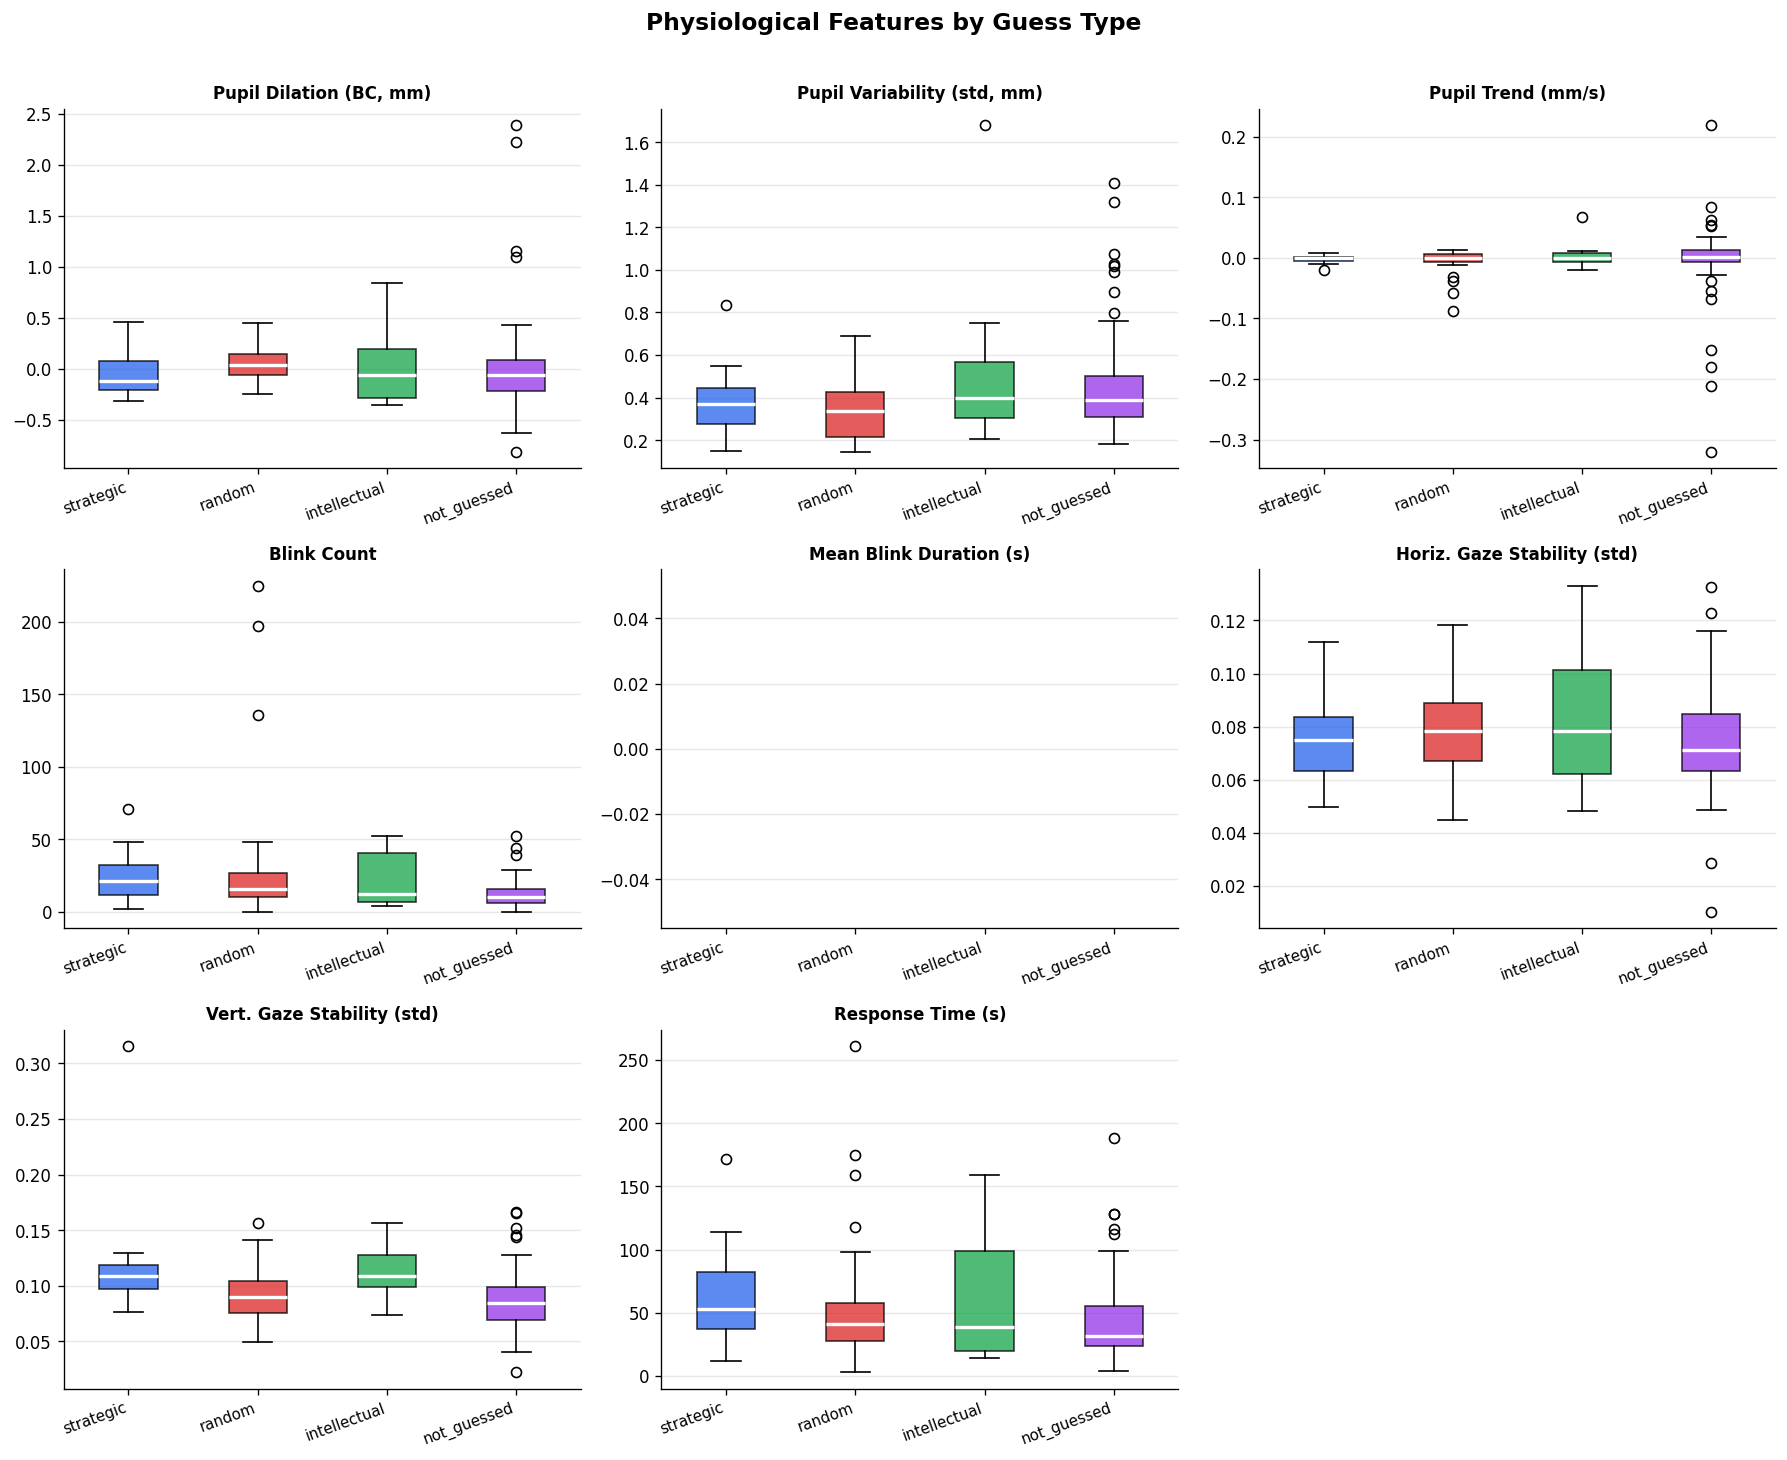

In [22]:
plot_boxplots_guess_type(df_all)

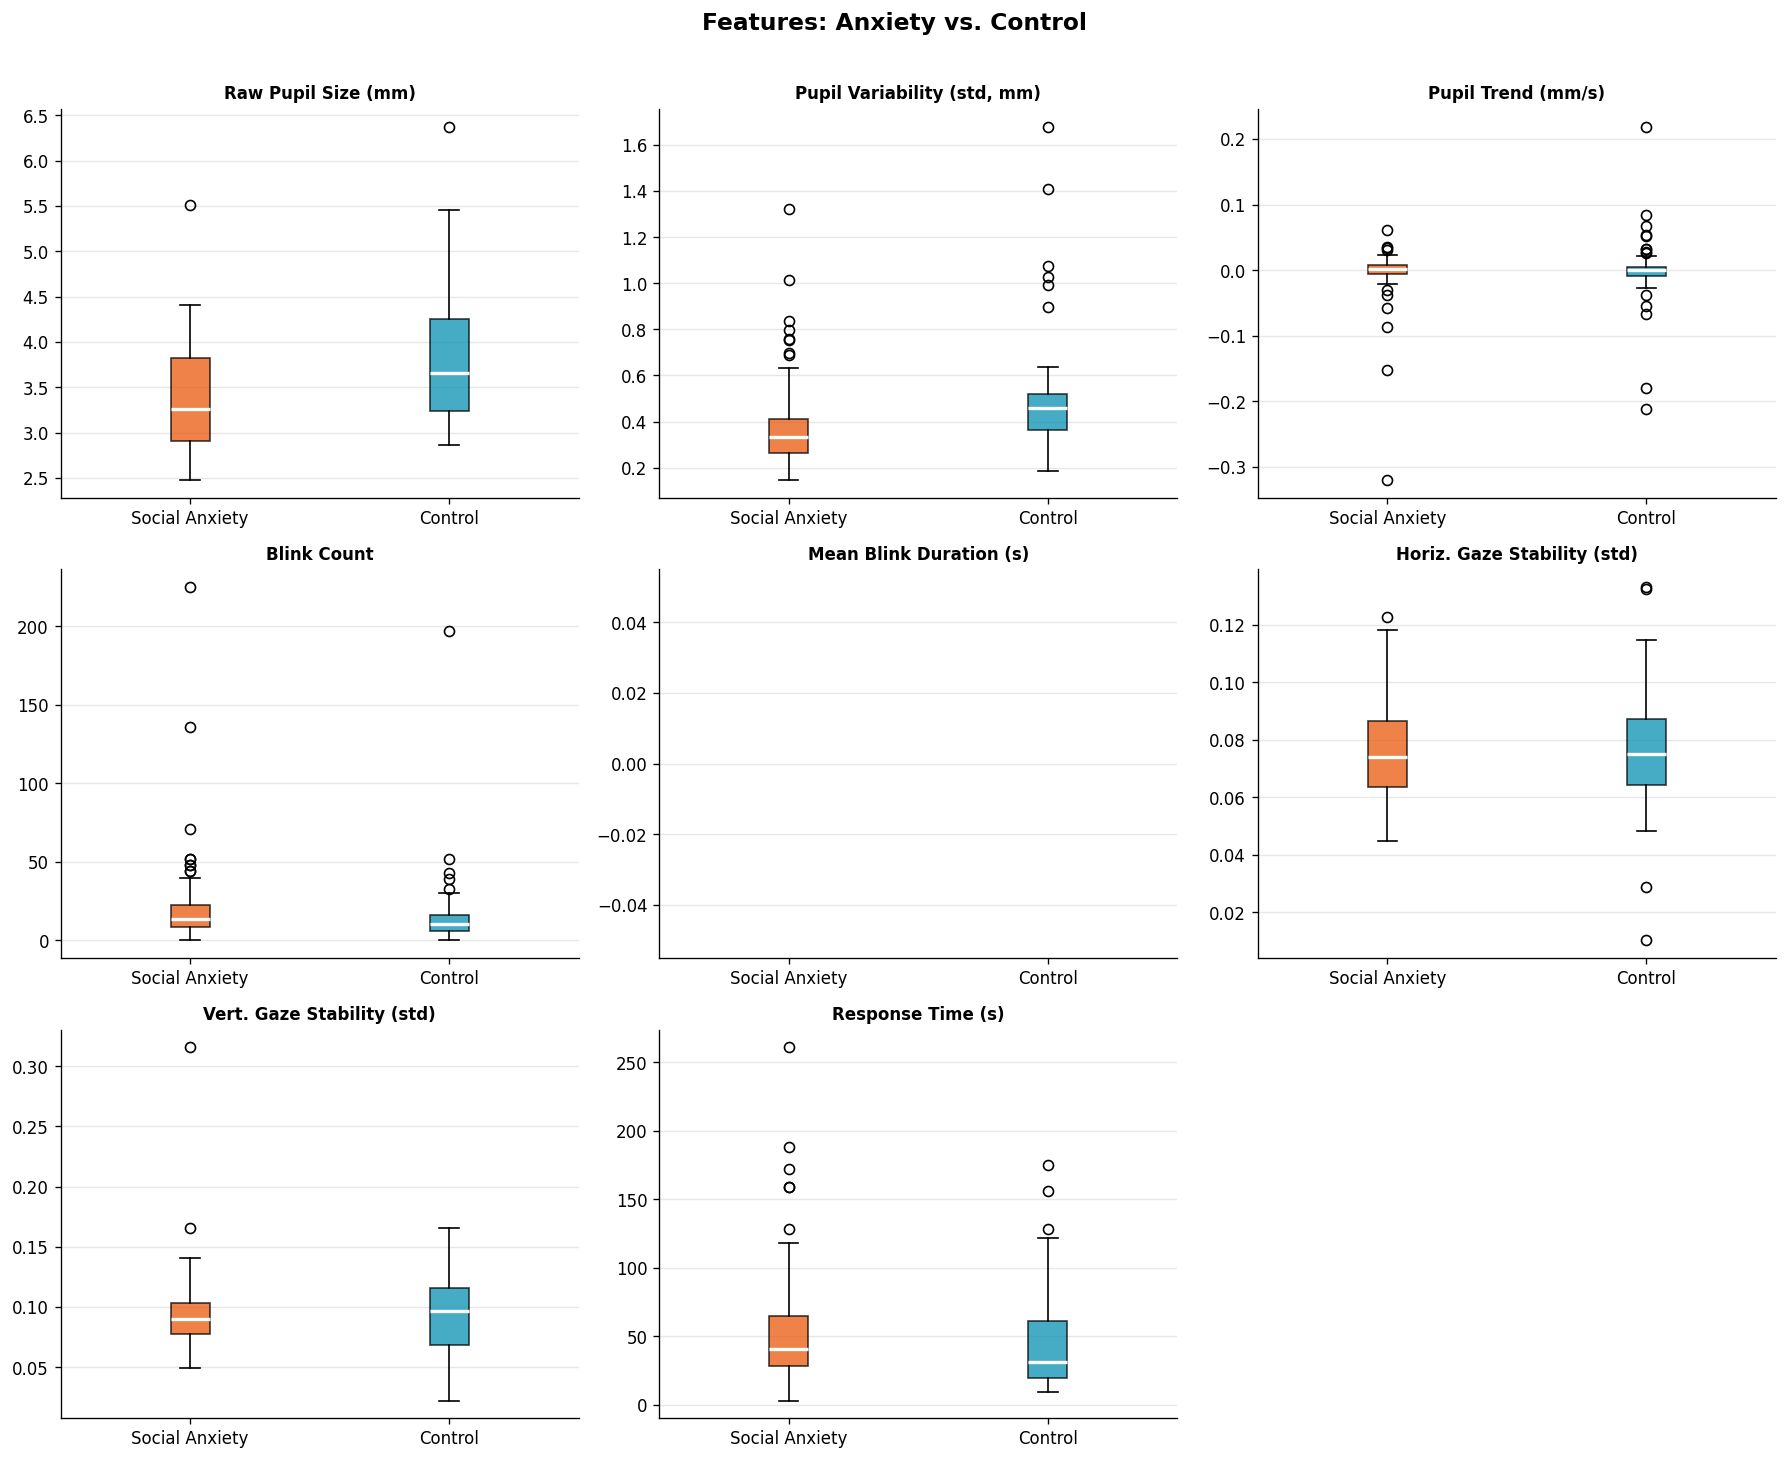

In [23]:
plot_boxplots_group(df_all)

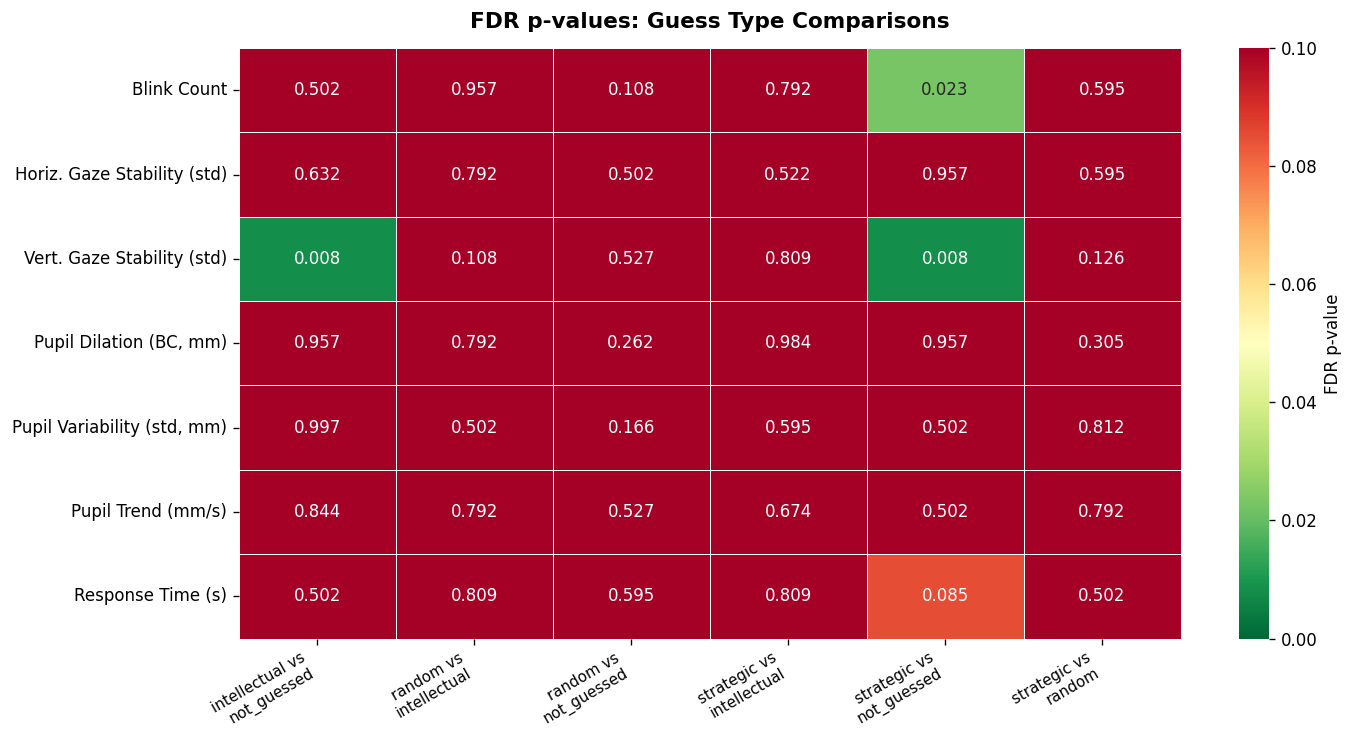

In [24]:
if not gt_results.empty:
    plot_pvalue_heatmap(gt_results, "FDR p-values: Guess Type Comparisons", "heatmap_guess_types.png")


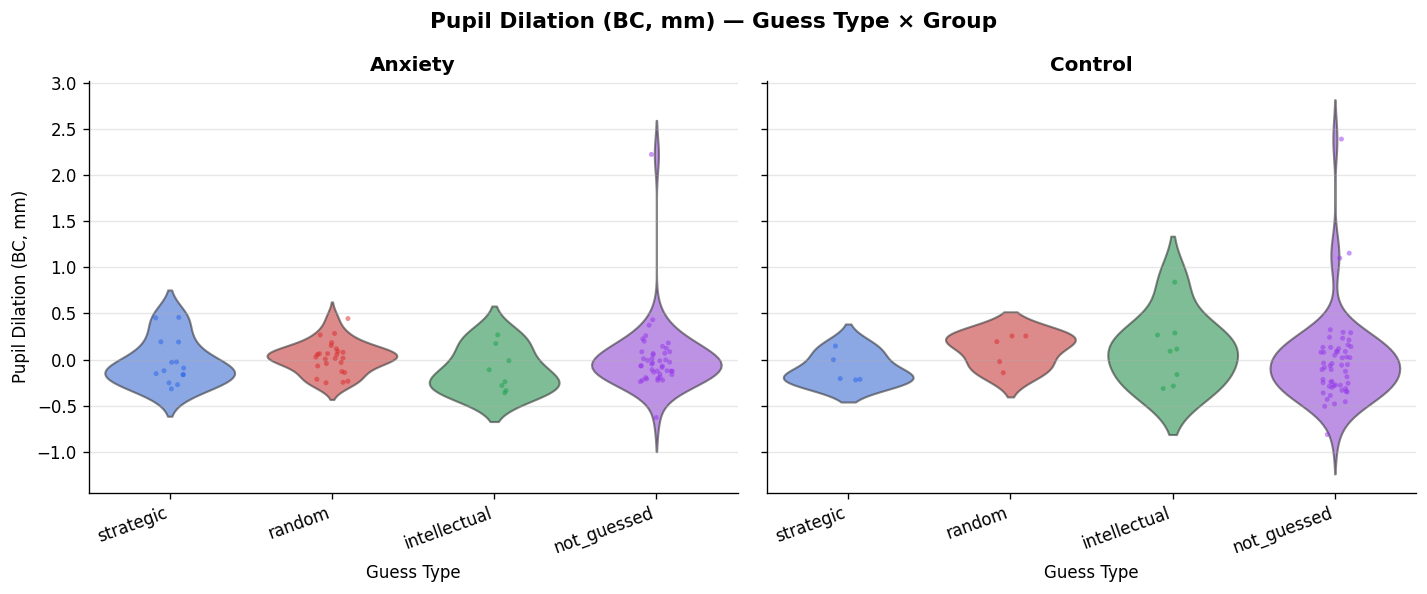

In [25]:
plot_faceted_by_group(df_all, feat='pupil_mean_bc')

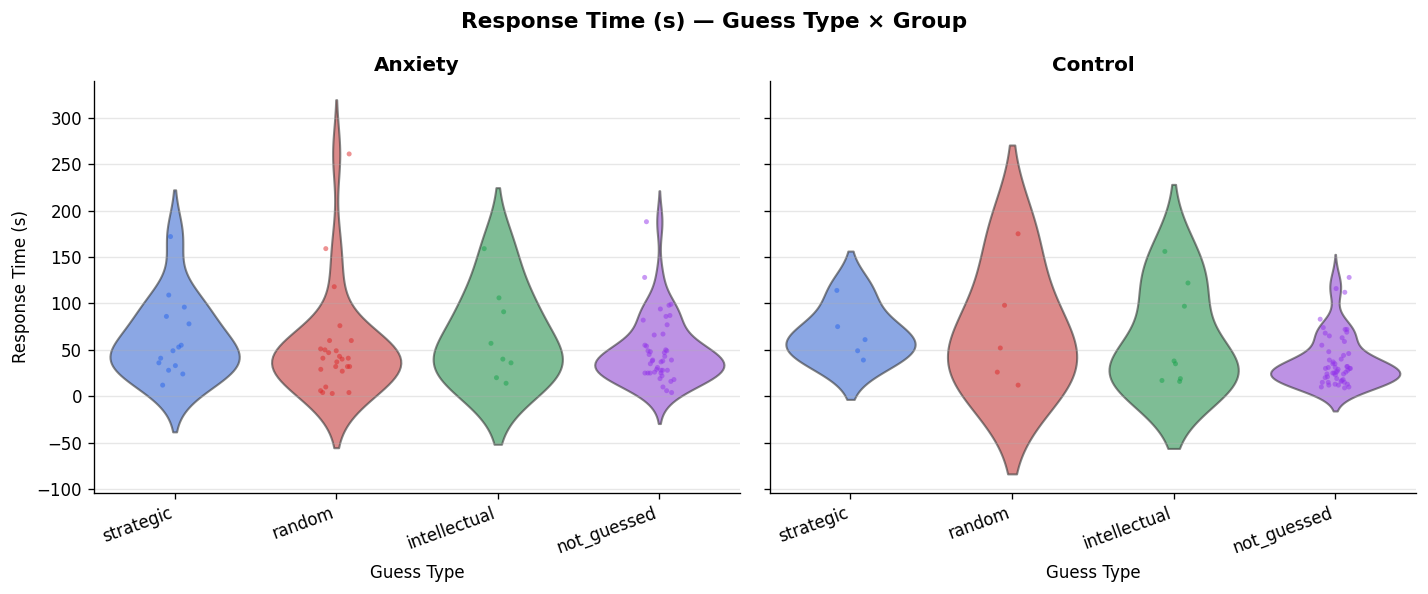

In [26]:
plot_faceted_by_group(df_all, feat='response_time')

## Cell 14 · Summary & Export

In [27]:
summary = df_all.groupby(["group","guess_type"])[FEATURE_COLS].agg(["mean","std","count"])
summary.columns = ["_".join(c) for c in summary.columns]
summary = summary.reset_index()
display(summary)

df_all.to_csv(OUTPUT_DIR/"all_features.csv", index=False)
summary.to_csv(OUTPUT_DIR/"summary_table.csv", index=False)

print("\n✅ All outputs saved to:", OUTPUT_DIR)
print("   ├── all_features.csv          (full feature table)")
print("   ├── summary_table.csv         (mean±sd per group × guess type)")
print("   ├── stats_guess_types.csv")
print("   ├── stats_groups.csv")
print("   ├── stats_interaction.csv")
print("   ├── boxplots_guess_type.png")
print("   ├── boxplots_group.png")
print("   ├── heatmap_guess_types.png")
print("   ├── faceted_pupil_mean_bc.png")
print("   └── faceted_response_time.png")


,group,guess_type,pupil_mean_bc_mean,pupil_mean_bc_std,pupil_mean_bc_count,pupil_std_mean,pupil_std_std,pupil_std_count,pupil_trend_mean,pupil_trend_std,...,blink_dur_mean_count,gaze_x_std_mean,gaze_x_std_std,gaze_x_std_count,gaze_y_std_mean,gaze_y_std_std,gaze_y_std_count,response_time_mean,response_time_std,response_time_count
0,anxiety,intellectual,-0.112732,0.236726,8,0.394128,0.179236,8,-0.004859,0.009805,...,0,0.074507,0.018063,8,0.102092,0.022410,8,65.375000,49.782204,8
1,anxiety,not_guessed,0.015551,0.391570,43,0.418701,0.222571,43,-0.002946,0.057158,...,0,0.077128,0.017579,43,0.088416,0.018001,43,48.906977,35.402996,43
2,anxiety,random,0.021503,0.171387,25,0.316117,0.132517,25,-0.006914,0.023305,...,0,0.078759,0.015996,25,0.087130,0.020319,25,52.480000,55.587109,25
3,anxiety,strategic,-0.021745,0.251291,14,0.353609,0.176793,14,-0.002974,0.007488,...,0,0.070728,0.014472,14,0.116198,0.059628,14,62.285714,42.655018,14
4,control,intellectual,0.103893,0.377675,8,0.589446,0.467264,8,0.010954,0.023739,...,0,0.091631,0.028645,8,0.123344,0.023330,8,62.500000,54.712234,8
5,control,not_guessed,-0.016081,0.473388,54,0.474279,0.228112,54,-0.002839,0.054502,...,0,0.073307,0.018900,54,0.086552,0.030104,54,38.296296,27.561684,54
6,control,random,0.107249,0.180749,5,0.542643,0.079207,5,-0.002205,0.008492,...,0,0.082436,0.023667,5,0.123604,0.025010,5,72.600000,65.953014,5
7,control,strategic,-0.099800,0.165125,5,0.427161,0.102695,5,-0.000249,0.002573,...,0,0.084776,0.017824,5,0.115022,0.012306,5,67.600000,29.219856,5



✅ All outputs saved to: /content/drive/MyDrive/eyetracking/gaze_analysis_output_results
   ├── all_features.csv          (full feature table)
   ├── summary_table.csv         (mean±sd per group × guess type)
   ├── stats_guess_types.csv
   ├── stats_groups.csv
   ├── stats_interaction.csv
   ├── boxplots_guess_type.png
   ├── boxplots_group.png
   ├── heatmap_guess_types.png
   ├── faceted_pupil_mean_bc.png
   └── faceted_response_time.png


## Box plot across all guess types group wise

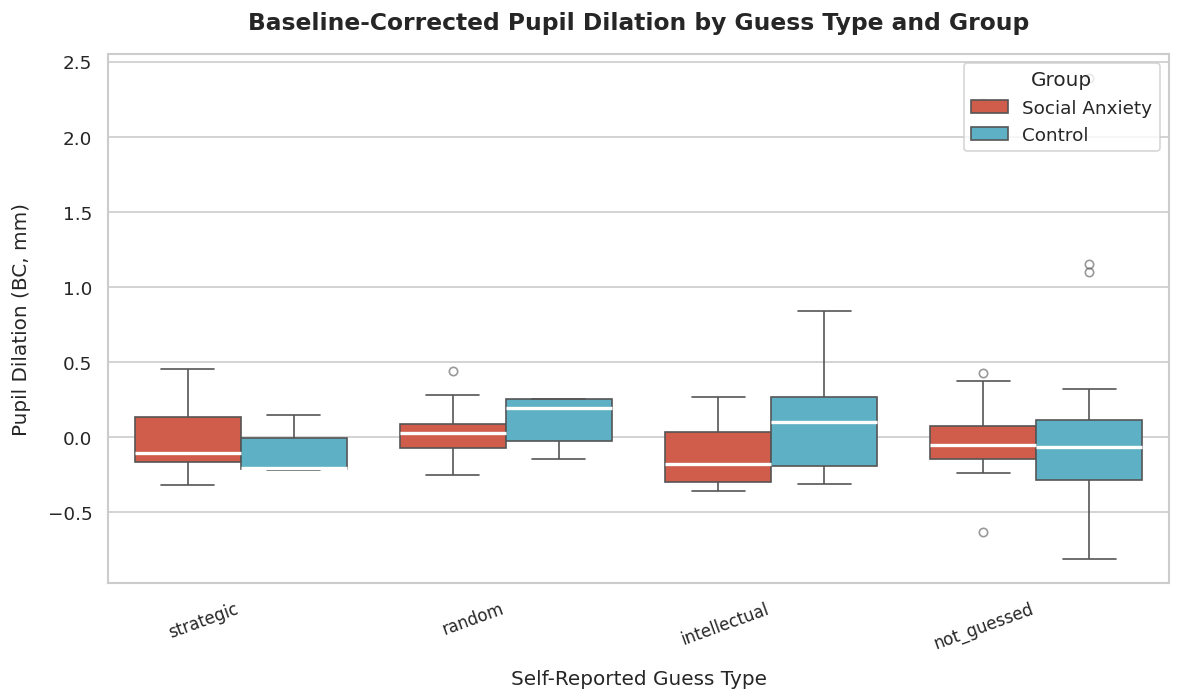

In [28]:
def plot_boxplots_interaction_pupil(df, save=True):
    import seaborn as sns
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")

    # Define group order and colors matching your previous plots
    group_order = ["anxiety", "control"]
    palette = {"anxiety": "#E64B35", "control": "#4DBBD5"}

    # Ensure correct ordering of guess types
    order = [g for g in GUESS_TYPES if g in df["guess_type"].unique()]

    ax = sns.boxplot(
        data=df,
        x="guess_type",
        y="pupil_mean_bc",
        hue="group",
        hue_order=group_order,
        order=order,
        palette=palette,
        medianprops=dict(color="white", linewidth=2),
        flierprops=dict(marker='o', markersize=5, alpha=0.6)
    )

    # Formatting to match academic style
    plt.title("Baseline-Corrected Pupil Dilation by Guess Type and Group", fontsize=14, fontweight="bold", pad=15)
    plt.xlabel("Self-Reported Guess Type", fontsize=12, labelpad=10)
    plt.ylabel("Pupil Dilation (BC, mm)", fontsize=12, labelpad=10)
    plt.xticks(rotation=20, ha="right", fontsize=10)

    # Clean up legend
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, ["Social Anxiety", "Control"], title="Group", loc="upper right")

    plt.tight_layout()
    if save:
        plt.savefig(OUTPUT_DIR / "boxplots_interaction_pupil_bc.png", dpi=150, bbox_inches="tight")
    plt.show()

# Run the function using your merged dataframe
plot_boxplots_interaction_pupil(df_all)

---
## Part 2 · Pre-MCQ Phase Analysis
### Gaze features during Baseline, Paragraph Reading, and Subjective Questions

The experiment has three phases **before** the MCQ section:

| Phase | Event markers | Typical duration |
|---|---|---|
| **Baseline** | `session_started` → `eyes_closed_finished` | ~180 s |
| **Reading** | `eyes_closed_finished` → `paragraph_finished` | ~60 s |
| **Subjective Qs** | `paragraph_finished` → `subjective_section_finished` | ~370 s total |

The subjective section is further broken into **11 individual questions**, each
bounded by consecutive `question_N_finished` timestamps.

**Feature availability per phase:**

| Feature | Baseline | Reading | Subjective |
|---|---|---|---|
| Pupil mean / std / trend | ✅ | ✅ | ✅ |
| Blink count / duration | ❌ eyes closed | ✅ | ✅ |
| Gaze X/Y stability | ❌ eyes closed | ✅ | ✅ |
| Response time per Q | — | — | ✅ |

**Better baseline correction:** The eyes-closed pupil mean is a physiologically
purer resting baseline than the MCQ-mean we currently use. Each participant's
eyes-closed pupil mean is stored as `pupil_baseline_ec` and used to compute
`pupil_mean_ec_bc` (eyes-closed baseline corrected dilation) for all phases.


### Cell A · Parse Pre-MCQ Time Windows from Click Log

In [29]:
def parse_preMCQ_windows(filepath: str) -> dict:
    """
    Extract time windows for the three pre-MCQ phases and each individual
    subjective question from a click log file.
    """
    with open(filepath, 'r', encoding='utf-8', errors='replace') as f:
        first = f.readline()
    sep = '\t' if '\t' in first else ','

    df = pd.read_csv(filepath, sep=sep)
    df.columns = df.columns.str.strip()

    def safe_json(x):
        try:
            return json.loads(x) if isinstance(x, str) and x.strip() not in ('', '{}') else {}
        except Exception:
            return {}

    df['vf'] = df['VariableFields'].apply(safe_json)
    pid = str(df['UserID'].iloc[0])

    # Wall-clock anchor
    sess = df[df['EventType'] == 'session_started']
    if len(sess):
        session_wc = parse_click_timestamp(sess['timestamp'].iloc[0])
    else:
        start = df[df['EventType'] == 'START']
        session_wc = parse_click_timestamp(start['timestamp'].iloc[0]) if len(start) else None

    def get_t(event_name):
        """Return TimeElapsed of the first occurrence of event_name, or NaN."""
        rows = df[df['EventType'] == event_name]
        return float(rows['TimeElapsed'].iloc[0]) if len(rows) else np.nan

    # FIX: Safe fallback for t_session
    t_session = get_t('session_started')
    if pd.isna(t_session):
        t_session = get_t('START')

    t_ec_end   = get_t('eyes_closed_finished')
    t_para_end = get_t('paragraph_finished')
    t_subj_end = get_t('subjective_section_finished')

    # FIX: Safely calculate durations preventing float - NaN math errors
    phases = {
        'baseline': {
            't_start'   : t_session,
            't_end'     : t_ec_end,
            'duration_s': t_ec_end - t_session if not (pd.isna(t_ec_end) or pd.isna(t_session)) else np.nan,
        },
        'reading': {
            't_start'   : t_ec_end,
            't_end'     : t_para_end,
            'duration_s': t_para_end - t_ec_end if not (pd.isna(t_para_end) or pd.isna(t_ec_end)) else np.nan,
        },
        'subjective': {
            't_start'   : t_para_end,
            't_end'     : t_subj_end,
            'duration_s': t_subj_end - t_para_end if not (pd.isna(t_subj_end) or pd.isna(t_para_end)) else np.nan,
        },
    }

    # Individual subjective question windows
    subj_rows = df[df['EventType'].str.match(r'question_\d+_finished', na=False)].copy()
    subj_rows['q_num'] = subj_rows['EventType'].str.extract(r'question_(\d+)_finished').astype(int)
    subj_rows = subj_rows.sort_values('q_num')

    subj_questions = []
    prev_end = t_para_end
    for _, row in subj_rows.iterrows():
        q_num  = int(row['q_num'])
        q_end  = float(row['TimeElapsed'])
        q_start = prev_end
        subj_questions.append({
            'q_num'     : q_num,
            't_start'   : q_start,
            't_end'     : q_end,
            'duration_s': q_end - q_start if not pd.isna(q_start) else np.nan,
        })
        prev_end = q_end

    return {
        'participant_id'    : pid,
        'session_wall_clock': session_wc,
        'phases'            : phases,
        'subj_questions'    : subj_questions,
    }

print('✅ parse_preMCQ_windows defined')


✅ parse_preMCQ_windows defined


### Cell B · Extract Gaze Features for Each Pre-MCQ Phase

In [30]:
def extract_preMCQ_features(gaze: pd.DataFrame, preMCQ: dict,
                             gaze_offset: float, group: str) -> pd.DataFrame:
    """
    Slice gaze data into pre-MCQ windows and extract features.
    """
    pid          = preMCQ['participant_id']
    gaze_elapsed = gaze['TIME'] - gaze_offset
    records      = []

    # HELPER: Enforces strict data quality checks before extracting features
    def _process_segment(t_s, t_e):
        if pd.isna(t_s) or pd.isna(t_e) or t_e <= t_s:
            return _empty_features()

        seg = gaze[gaze_elapsed.between(t_s, t_e)].copy()

        # FIX 1: Enforce valid pupil data check (rejects tracker loss)
        n_valid_pupil = 0
        if "LPMM" in seg.columns: n_valid_pupil += seg["LPMM"].notna().sum()
        if "RPMM" in seg.columns: n_valid_pupil += seg["RPMM"].notna().sum()

        if n_valid_pupil < 5:
            return _empty_features()

        feats = extract_features(seg)

        # FIX 2: Recalibration artifact filter
        if feats.get("pupil_std", 0) is not np.nan and feats.get("pupil_std", 0) > 2.0:
            feats["pupil_mean"] = np.nan
            feats["pupil_std"]  = np.nan
            feats["pupil_trend"] = np.nan

        return feats

    # ── Phase-level segments ──────────────────────────────────────────────────
    for phase_name, win in preMCQ['phases'].items():
        feats = _process_segment(win['t_start'], win['t_end'])

        # Null out gaze + blink for baseline — eyes were closed
        if phase_name == 'baseline':
            for key in ['gaze_x_mean','gaze_x_std','gaze_y_mean','gaze_y_std',
                        'blink_count','blink_dur_mean']:
                feats[key] = np.nan

        records.append({
            'participant_id': pid,
            'phase'         : phase_name,
            'q_num'         : np.nan,
            't_start'       : win['t_start'],
            't_end'         : win['t_end'],
            'duration_s'    : win['duration_s'],
            'response_time' : win['duration_s'],
            'group'         : group,
            **feats,
        })

    # ── Per-subjective-question segments ─────────────────────────────────────
    for q in preMCQ['subj_questions']:
        feats = _process_segment(q['t_start'], q['t_end'])

        records.append({
            'participant_id': pid,
            'phase'         : 'subjective_q',
            'q_num'         : q['q_num'],
            't_start'       : q['t_start'],
            't_end'         : q['t_end'],
            'duration_s'    : q['duration_s'],
            'response_time' : q['duration_s'],
            'group'         : group,
            **feats,
        })

    df_out = pd.DataFrame(records)

    # Eyes-closed baseline correction
    baseline_row = df_out[df_out['phase'] == 'baseline']
    if len(baseline_row) and not baseline_row['pupil_mean'].isna().all():
        ec_pupil = baseline_row['pupil_mean'].iloc[0]
        df_out['pupil_mean_ec_bc']  = df_out['pupil_mean'] - ec_pupil
        df_out['pupil_baseline_ec'] = ec_pupil
    else:
        df_out['pupil_mean_ec_bc']  = np.nan
        df_out['pupil_baseline_ec'] = np.nan

    return df_out


print('✅ extract_preMCQ_features defined')


✅ extract_preMCQ_features defined


### Cell C · Run Pre-MCQ Pipeline

In [31]:
# Reuses: participants, label_map, load_gaze,
#         extract_gaze_wall_start, compute_gaze_offset — all defined earlier.

preMCQ_records = []

for p in participants:
    pid = p['pid']
    print(f"\n{'─'*55}  {pid}")

    try:
        preMCQ = parse_preMCQ_windows(str(p['click_path']))

        for phase, win in preMCQ['phases'].items():
            print(f"  {phase:<12}: {win['t_start']:.0f}s -> {win['t_end']:.0f}s  "
                  f"({win['duration_s']:.0f}s)")
        print(f"  subjective_q: {len(preMCQ['subj_questions'])} questions detected")

        gaze            = load_gaze(str(p['gaze_path']))
        gaze_wall_start = extract_gaze_wall_start(str(p['gaze_path']))
        gaze_offset     = compute_gaze_offset(gaze_wall_start, preMCQ['session_wall_clock'], pid)

        group  = label_map.get(pid, 'unknown')
        result = extract_preMCQ_features(gaze, preMCQ, gaze_offset, group)

        n_valid = result['pupil_mean'].notna().sum()
        ec_val  = result['pupil_baseline_ec'].iloc[0]
        print(f"  Valid pupil segments: {n_valid}/{len(result)}  "
              f"| Eyes-closed pupil: {ec_val:.3f} mm")

        preMCQ_records.append(result)

    except Exception as e:
        import traceback
        print(f'  ERROR: {e}')
        traceback.print_exc()

df_preMCQ = pd.concat(preMCQ_records, ignore_index=True)

print(f"\n{'='*55}")
print(f'Total pre-MCQ rows: {len(df_preMCQ)}')
print('\nRows per phase:')
print(df_preMCQ['phase'].value_counts().to_string())
print('\nRows per group:')
print(df_preMCQ['group'].value_counts().to_string())



───────────────────────────────────────────────────────  P3718de9d6a
  baseline    : 0s -> 180s  (180s)
  reading     : 180s -> 244s  (64s)
  subjective  : 244s -> 616s  (372s)
  subjective_q: 11 questions detected
  [P3718de9d6a] Gaze start (IST)   : 2026-04-02 16:37:18.222000+05:30
  [P3718de9d6a] Session start (UTC): 2026-04-02 11:09:33+00:00 -> (IST: 2026-04-02 16:39:33+05:30)
  [P3718de9d6a] Computed Offset    : 134.8 s
  Valid pupil segments: 14/14  | Eyes-closed pupil: 3.990 mm

───────────────────────────────────────────────────────  P5512066f34
  baseline    : 0s -> 180s  (180s)
  reading     : 180s -> 251s  (71s)
  subjective  : 251s -> 573s  (322s)
  subjective_q: 11 questions detected
  [P5512066f34] Gaze start (IST)   : 2026-04-01 13:00:38.257000+05:30
  [P5512066f34] Session start (UTC): 2026-04-01 07:31:31+00:00 -> (IST: 2026-04-01 13:01:31+05:30)
  [P5512066f34] Computed Offset    : 52.7 s
  Valid pupil segments: 14/14  | Eyes-closed pupil: 4.274 mm

──────────────────

### Cell D · Sanity Check

In [32]:
print('=== Phase durations per participant ===')
dur_check = df_preMCQ[df_preMCQ['phase'].isin(['baseline','reading','subjective'])].pivot_table(
    index='participant_id', columns='phase', values='duration_s', aggfunc='first'
)
display(dur_check)

print('\n=== Eyes-closed pupil baseline per participant ===')
ec = df_preMCQ[df_preMCQ['phase']=='baseline'][['participant_id','group','pupil_mean','pupil_baseline_ec']]
display(ec)

print('\n=== Phase-level feature means by group ===')
cols_to_show = ['pupil_mean','pupil_mean_ec_bc','pupil_std','blink_count','gaze_y_std']
cols_present = [c for c in cols_to_show if c in df_preMCQ.columns]
phase_summ = df_preMCQ[df_preMCQ['phase'].isin(['baseline','reading','subjective'])].groupby(
    ['group','phase']
)[cols_present].mean().round(3)
display(phase_summ)

print('\n=== Subjective question response times (mean per group) ===')
subj_rt = df_preMCQ[df_preMCQ['phase']=='subjective_q'].groupby(
    ['group','q_num']
)['response_time'].mean().unstack(level=0).round(1)
display(subj_rt)


=== Phase durations per participant ===


phase,baseline,reading,subjective
participant_id,,,
P3718de9d6a,180.0,64.0,372.0
P5512066f34,180.0,71.0,322.0
P564190862f,181.0,70.0,421.0
Padff0cfc3f,182.0,68.0,303.0
Pbdcb1b03d4,180.0,69.0,410.0
Pffea64f40a,180.0,53.0,280.0



=== Eyes-closed pupil baseline per participant ===


,participant_id,group,pupil_mean,pupil_baseline_ec
0,P3718de9d6a,anxiety,3.989647,3.989647
14,P5512066f34,control,4.274317,4.274317
28,Pbdcb1b03d4,anxiety,4.273336,4.273336
42,Pffea64f40a,control,3.603381,3.603381
56,P564190862f,anxiety,4.880051,4.880051
70,Padff0cfc3f,control,5.303280,5.303280



=== Phase-level feature means by group ===


pupil_mean  pupil_mean_ec_bc  pupil_std  blink_count  \
group   phase                                                              
anxiety baseline         4.381             0.000      0.822          NaN   
        reading          3.129            -1.252      0.340       17.333   
        subjective       4.044            -0.337      0.556      185.667   
control baseline         4.394             0.000      0.446          NaN   
        reading          3.639            -0.754      0.501       25.667   
        subjective       4.262            -0.132      0.533      121.333   

                    gaze_y_std  
group   phase                   
anxiety baseline           NaN  
        reading          0.128  
        subjective       0.216  
control baseline           NaN  
        reading          0.151  
        subjective       0.110


=== Subjective question response times (mean per group) ===


group,anxiety,control
q_num,,
1.0,41.3,34.7
2.0,29.0,27.0
3.0,37.3,29.0
4.0,46.3,30.7
5.0,47.0,28.0
6.0,40.3,35.5
7.0,34.3,40.7
8.0,31.7,21.7
9.0,29.7,26.7


### Cell E · Statistical Analysis — Pre-MCQ Phases

In [33]:
PREMCQ_FEATURES = [
    'pupil_mean',
    'pupil_mean_ec_bc',  # eyes-closed baseline corrected
    'pupil_std',
    'pupil_trend',
    'blink_count',
    'blink_dur_mean',
    'gaze_x_std',
    'gaze_y_std',
    'response_time',
]

PREMCQ_FEATURE_LABELS = {
    'pupil_mean'       : 'Pupil Dilation (raw, mm)',
    'pupil_mean_ec_bc' : 'Pupil Dilation (EC-corrected, mm)',
    'pupil_std'        : 'Pupil Variability (std, mm)',
    'pupil_trend'      : 'Pupil Trend (mm/s)',
    'blink_count'      : 'Blink Count',
    'blink_dur_mean'   : 'Mean Blink Duration (s)',
    'gaze_x_std'       : 'Horiz. Gaze Stability (std)',
    'gaze_y_std'       : 'Vert. Gaze Stability (std)',
    'response_time'    : 'Time on Phase / Question (s)',
}


def compare_groups_preMCQ(df, phases):
    """
    Anxiety vs Control for each phase × feature combination.
    Single FDR correction across all phase-feature pairs.
    """
    rows = []
    for phase in phases:
        sub = df[df['phase'] == phase]
        for feat in PREMCQ_FEATURES:
            if feat not in sub.columns: continue
            a = sub[sub['group'] == 'anxiety'][feat]
            b = sub[sub['group'] == 'control'][feat]
            st, p, test = _test_pair(a, b)
            rows.append({'phase':phase,'feature':feat,
                         'n_anxiety':len(a.dropna()),'n_control':len(b.dropna()),
                         'mean_anxiety':a.mean(),'mean_control':b.mean(),
                         'statistic':st,'p_raw':p,'cohen_d':cohens_d(a,b),'test':test})
    if not rows: return pd.DataFrame()
    res = pd.DataFrame(rows).dropna(subset=['p_raw'])
    _, p_adj, _, _ = multipletests(res['p_raw'], method='fdr_bh')
    res['p_adj_fdr']   = p_adj
    res['significant'] = res['p_adj_fdr'] < 0.05
    return res.sort_values('p_adj_fdr').reset_index(drop=True)


def test_phase_progression(df, phases):
    """
    Friedman test: does each feature change significantly across phases?
    Non-parametric repeated-measures equivalent (within-participant).
    Only participants with valid data in ALL phases are included.
    """
    from scipy.stats import friedmanchisquare
    rows = []
    for feat in PREMCQ_FEATURES:
        if feat not in df.columns: continue
        pivot = df[df['phase'].isin(phases)].pivot_table(
            index='participant_id', columns='phase', values=feat, aggfunc='mean'
        ).dropna()
        if len(pivot) < 3: continue
        cols = [pivot[p].values for p in phases if p in pivot.columns]
        if len(cols) < 2: continue
        try:
            stat, p = friedmanchisquare(*cols)
        except Exception:
            stat, p = np.nan, np.nan
        rows.append({'feature':feat,'n_participants':len(pivot),
                     'phases':' -> '.join(phases),'statistic':stat,'p_raw':p})
    if not rows: return pd.DataFrame()
    res = pd.DataFrame(rows).dropna(subset=['p_raw'])
    if len(res) > 1:
        _, p_adj, _, _ = multipletests(res['p_raw'], method='fdr_bh')
        res['p_adj_fdr'] = p_adj
    else:
        res['p_adj_fdr'] = res['p_raw']
    res['significant'] = res['p_adj_fdr'] < 0.05
    return res.sort_values('p_adj_fdr').reset_index(drop=True)


phase_order = ['baseline', 'reading', 'subjective']

preMCQ_group_stats       = compare_groups_preMCQ(df_preMCQ, phase_order)
preMCQ_progression_stats = test_phase_progression(df_preMCQ, phase_order)

print('=== Anxiety vs Control per phase (FDR-corrected) ===')
print(f"Significant: {preMCQ_group_stats['significant'].sum()} / {len(preMCQ_group_stats)}")
display(preMCQ_group_stats)
preMCQ_group_stats.to_csv(OUTPUT_DIR/'stats_preMCQ_groups.csv', index=False)

print('\n=== Phase progression Friedman test (baseline -> reading -> subjective) ===')
display(preMCQ_progression_stats)
preMCQ_progression_stats.to_csv(OUTPUT_DIR/'stats_preMCQ_progression.csv', index=False)


=== Anxiety vs Control per phase (FDR-corrected) ===
Significant: 0 / 20


,phase,feature,n_anxiety,n_control,mean_anxiety,mean_control,statistic,p_raw,cohen_d,test,p_adj_fdr,significant
0,subjective,response_time,3,3,401.000000,301.666667,5.179672,0.006608,4.229185,t-test,0.132156,False
1,baseline,pupil_trend,3,3,0.011774,-0.015236,3.642732,0.021912,2.974278,t-test,0.219117,False
2,reading,blink_count,3,3,17.333333,25.666667,-2.525381,0.064983,-2.061965,t-test,0.259933,False
3,reading,pupil_mean_ec_bc,3,3,-1.252440,-0.754488,-2.926077,0.042982,-2.389132,t-test,0.259933,False
4,subjective,gaze_y_std,3,3,0.215643,0.110484,2.580695,0.061282,2.107129,t-test,0.259933,False
5,subjective,blink_count,3,3,185.666667,121.333333,1.725830,0.159458,1.409135,t-test,0.531528,False
6,baseline,pupil_std,3,3,0.822115,0.445745,1.187473,0.300737,0.969568,t-test,0.751843,False
7,reading,pupil_std,3,3,0.339768,0.501278,-1.228192,0.286700,-1.002814,t-test,0.751843,False
8,subjective,gaze_x_std,3,3,0.132794,0.096921,7.000000,0.400000,0.881572,Mann-Whitney U,0.864631,False
9,reading,pupil_mean,3,3,3.128571,3.639171,-0.872222,0.432315,-0.712166,t-test,0.864631,False



=== Phase progression Friedman test (baseline -> reading -> subjective) ===


,feature,n_participants,phases,statistic,p_raw,p_adj_fdr,significant
0,response_time,6,baseline -> reading -> subjective,12.000000,0.002479,0.012394,True
1,pupil_mean,6,baseline -> reading -> subjective,6.333333,0.042144,0.070240,False
2,pupil_mean_ec_bc,6,baseline -> reading -> subjective,6.333333,0.042144,0.070240,False
3,pupil_trend,6,baseline -> reading -> subjective,3.000000,0.223130,0.278913,False
4,pupil_std,6,baseline -> reading -> subjective,2.333333,0.311403,0.311403,False


### Cell F · Statistical Analysis — Per-Subjective-Question

In [34]:
subj_df = df_preMCQ[df_preMCQ['phase'] == 'subjective_q'].copy()

rows = []
for q_num in sorted(subj_df['q_num'].dropna().unique()):
    sub = subj_df[subj_df['q_num'] == q_num]
    for feat in ['pupil_mean','pupil_mean_ec_bc','pupil_std',
                 'blink_count','gaze_y_std','response_time']:
        if feat not in sub.columns: continue
        a = sub[sub['group'] == 'anxiety'][feat]
        b = sub[sub['group'] == 'control'][feat]
        st, p, test = _test_pair(a, b)
        rows.append({'q_num':int(q_num),'feature':feat,
                     'n_anxiety':len(a.dropna()),'n_control':len(b.dropna()),
                     'mean_anxiety':a.mean(),'mean_control':b.mean(),
                     'statistic':st,'p_raw':p,'cohen_d':cohens_d(a,b),'test':test})

if rows:
    subj_stats = pd.DataFrame(rows).dropna(subset=['p_raw'])
    _, p_adj, _, _ = multipletests(subj_stats['p_raw'], method='fdr_bh')
    subj_stats['p_adj_fdr']   = p_adj
    subj_stats['significant'] = subj_stats['p_adj_fdr'] < 0.05
    subj_stats = subj_stats.sort_values('p_adj_fdr').reset_index(drop=True)
    print(f"Significant: {subj_stats['significant'].sum()} / {len(subj_stats)}")
    display(subj_stats.head(20))
    subj_stats.to_csv(OUTPUT_DIR/'stats_preMCQ_subjective_questions.csv', index=False)
else:
    print('No subjective question data available.')


Significant: 0 / 54


,q_num,feature,n_anxiety,n_control,mean_anxiety,mean_control,statistic,p_raw,cohen_d,test,p_adj_fdr,significant
0,3,gaze_y_std,3,3,0.162750,0.059233,3.338766,0.028869,2.726091,t-test,0.779461,False
1,11,blink_count,3,3,15.333333,10.333333,4.008919,0.016011,3.273268,t-test,0.779461,False
2,1,pupil_std,3,3,0.567553,0.618359,-0.291571,0.785110,-0.238067,t-test,0.968316,False
3,1,pupil_mean,3,3,4.023747,4.298730,-0.444180,0.679885,-0.362671,t-test,0.968316,False
4,1,response_time,3,3,41.333333,34.666667,0.492068,0.648454,0.401772,t-test,0.968316,False
5,2,pupil_mean,3,3,4.103420,4.224818,-0.231967,0.827948,-0.189400,t-test,0.968316,False
6,2,pupil_mean_ec_bc,3,3,-0.277592,-0.168842,-0.187051,0.860725,-0.152727,t-test,0.968316,False
7,1,pupil_mean_ec_bc,3,3,-0.357264,-0.094930,-0.376896,0.725393,-0.307734,t-test,0.968316,False
8,3,pupil_mean,3,3,3.817718,4.087384,-0.460554,0.669044,-0.376041,t-test,0.968316,False
9,2,blink_count,3,3,13.666667,10.666667,0.585850,0.589438,0.478345,t-test,0.968316,False


### Cell G · Visualisations — Pre-MCQ Phases

In [35]:
def plot_preMCQ_phases(df, feat='pupil_mean', save=True):
    """
    Box plots: anxiety vs control for each pre-MCQ phase.
    Two boxes per phase (one per group) side by side.
    """
    phase_order = ['baseline', 'reading', 'subjective']
    df_ph = df[df['phase'].isin(phase_order)].copy()
    colors = {'anxiety':'#EA580C','control':'#0891B2'}
    w = 0.3

    fig, ax = plt.subplots(figsize=(9, 5))
    for i, phase in enumerate(phase_order):
        for j, grp in enumerate(['anxiety','control']):
            vals = df_ph[(df_ph['phase']==phase)&(df_ph['group']==grp)][feat].dropna()
            x = i + (j - 0.5) * w * 2
            bp = ax.boxplot(vals, positions=[x], widths=w, patch_artist=True,
                            medianprops=dict(color='white', linewidth=2),
                            flierprops=dict(marker='o', markersize=4, alpha=0.5))
            bp['boxes'][0].set_facecolor(colors[grp])
            bp['boxes'][0].set_alpha(0.75)

    ax.set_xticks(range(len(phase_order)))
    ax.set_xticklabels(['Baseline\n(eyes closed)','Paragraph\nReading',
                         'Subjective\nQuestions'], fontsize=11)
    ax.set_ylabel(PREMCQ_FEATURE_LABELS.get(feat, feat), fontsize=11)
    ax.set_title(f"{PREMCQ_FEATURE_LABELS.get(feat, feat)} — Pre-MCQ Phases",
                 fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(facecolor=colors[g], label=g.capitalize())
                        for g in ['anxiety','control']], loc='upper right')
    plt.tight_layout()
    if save: fig.savefig(OUTPUT_DIR/f'preMCQ_phases_{feat}.png', bbox_inches='tight', dpi=150)
    plt.show()


def plot_preMCQ_progression(df, feat='pupil_mean', save=True):
    """
    Grouped bar plot: feature means across phases for each group.
    Includes error bars to indicate variance within the cohort.
    """
    phase_order = ['baseline', 'reading', 'subjective']
    df_ph = df[df['phase'].isin(phase_order)].copy()

    # Enforce the categorical order so the bars appear logically left-to-right
    df_ph['phase'] = pd.Categorical(df_ph['phase'], categories=phase_order, ordered=True)

    # Keeping your exact hex colors
    colors = {'anxiety': '#EA580C', 'control': '#0891B2'}

    fig, ax = plt.subplots(figsize=(8, 5))

    # Seaborn barplot automatically handles grouping and mean calculation
    sns.barplot(
        data=df_ph,
        x='phase',
        y=feat,
        hue='group',
        palette=colors,
        capsize=0.08,     # Adds caps to error bars
        errwidth=1.5,     # Thickness of error bars
        ax=ax
    )

    # Format the X-axis with your original labels
    ax.set_xticklabels([
        'Baseline\n(eyes closed)',
        'Paragraph\nReading',
        'Subjective\nQuestions'
    ], fontsize=11)

    # Format Labels and Title
    ax.set_xlabel('') # Remove the default 'phase' x-axis label for cleaner look
    ax.set_ylabel(PREMCQ_FEATURE_LABELS.get(feat, feat), fontsize=11)
    ax.set_title(f"{PREMCQ_FEATURE_LABELS.get(feat, feat)} — Phase Progression",
                 fontsize=12, fontweight='bold')

    # Format Legend to capitalize group names exactly like your original
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, [l.capitalize() for l in labels], title='Cohort', loc='upper right')

    # Grid and Layout
    ax.grid(alpha=0.3, axis='y') # Vertical gridlines are distracting on bar plots, so we only use 'y'
    plt.tight_layout()

    if save:
        fig.savefig(OUTPUT_DIR / f'preMCQ_progression_{feat}.png', bbox_inches='tight', dpi=150)
    plt.show()


def plot_subjective_questions(df, feat='pupil_mean', save=True):
    """
    Line plot: mean feature value across the 11 subjective questions.
    Shaded band = ±1 SEM. Anxiety vs control as separate lines.
    """
    subj = df[df['phase']=='subjective_q'].copy()
    if subj.empty: print('No subjective question data.'); return
    colors = {'anxiety':'#EA580C','control':'#0891B2'}

    fig, ax = plt.subplots(figsize=(11, 5))
    for grp, color in colors.items():
        sub   = subj[subj['group']==grp]
        means = sub.groupby('q_num')[feat].mean()
        sems  = sub.groupby('q_num')[feat].sem()
        ax.plot(means.index, means.values, color=color, linewidth=2.2,
                marker='o', markersize=6, label=grp.capitalize())
        ax.fill_between(means.index, means-sems, means+sems, color=color, alpha=0.15)

    ax.set_xlabel('Subjective Question Number', fontsize=11)
    ax.set_ylabel(PREMCQ_FEATURE_LABELS.get(feat, feat), fontsize=11)
    ax.set_title(f"{PREMCQ_FEATURE_LABELS.get(feat, feat)} — Subjective Questions",
                 fontsize=12, fontweight='bold')
    ax.set_xticks(sorted(subj['q_num'].dropna().unique()))
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    if save: fig.savefig(OUTPUT_DIR/f'preMCQ_subjQ_{feat}.png', bbox_inches='tight', dpi=150)
    plt.show()

print('✅ Pre-MCQ visualisation functions defined')


✅ Pre-MCQ visualisation functions defined


### Cell H · Generate Pre-MCQ Plots

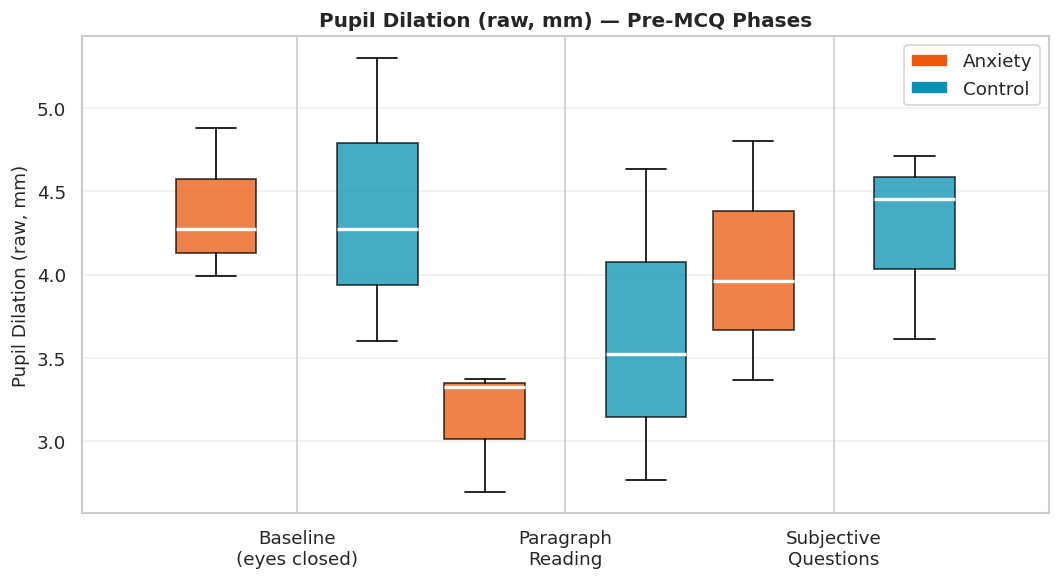

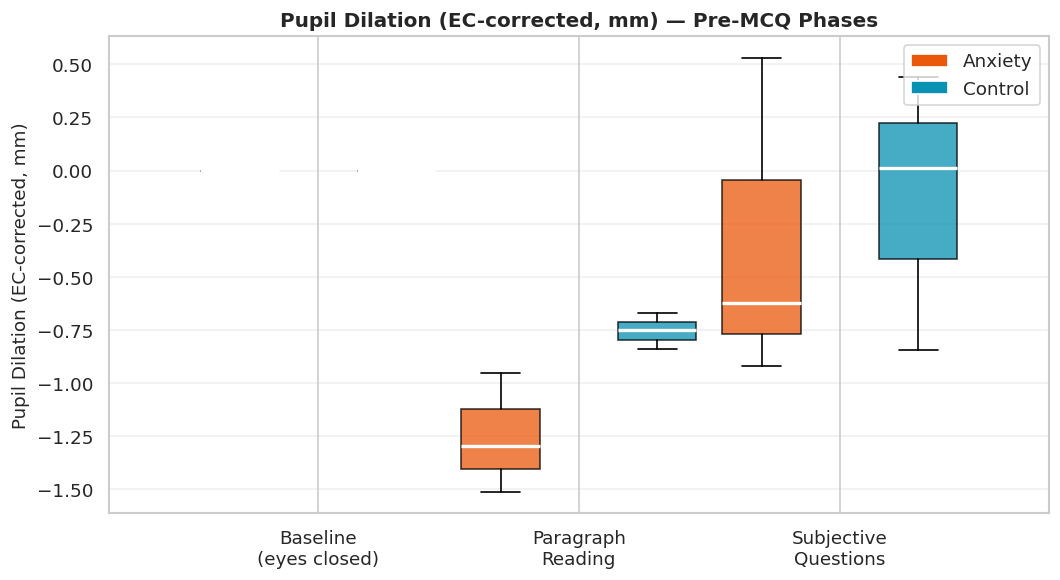

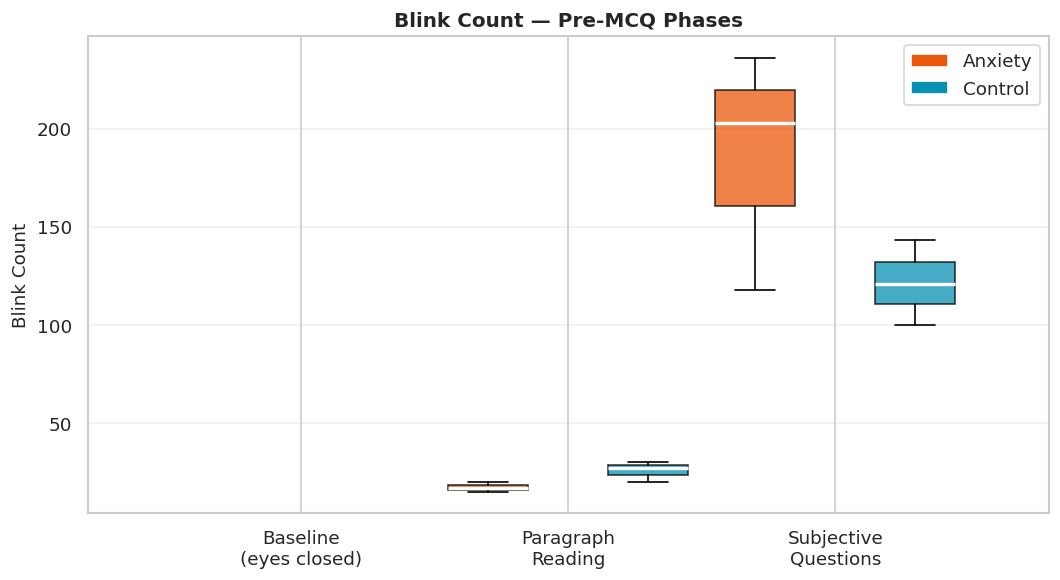

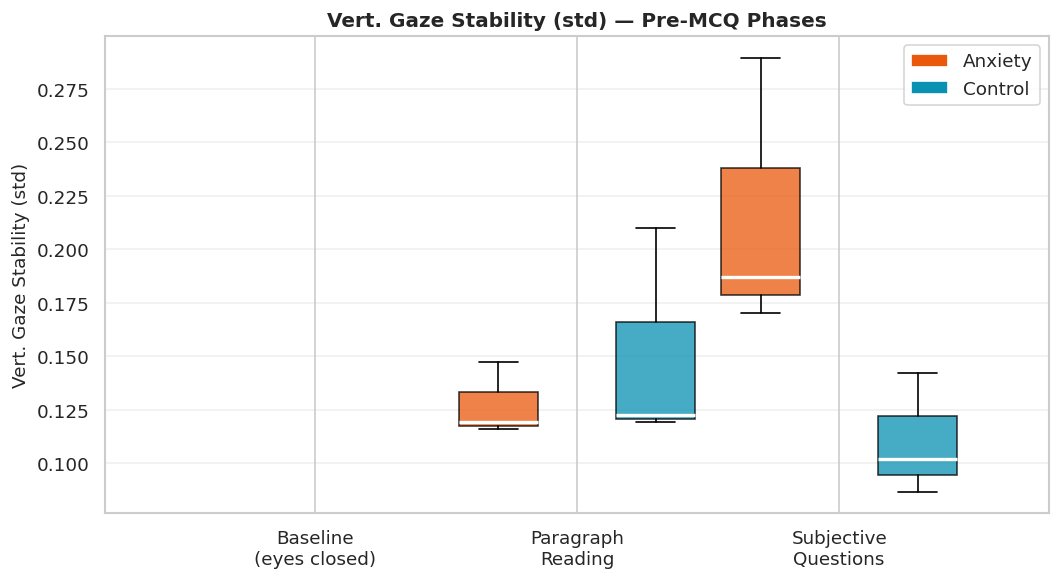

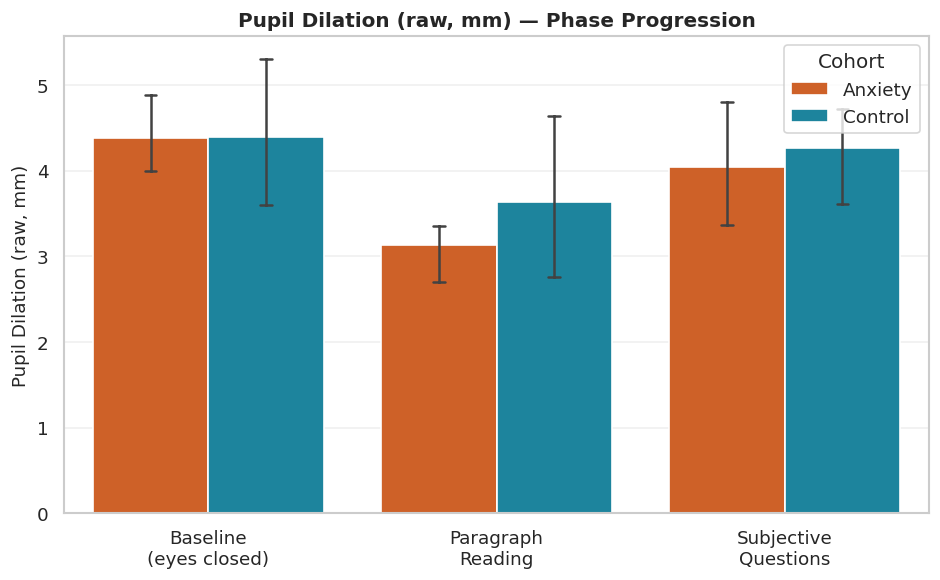

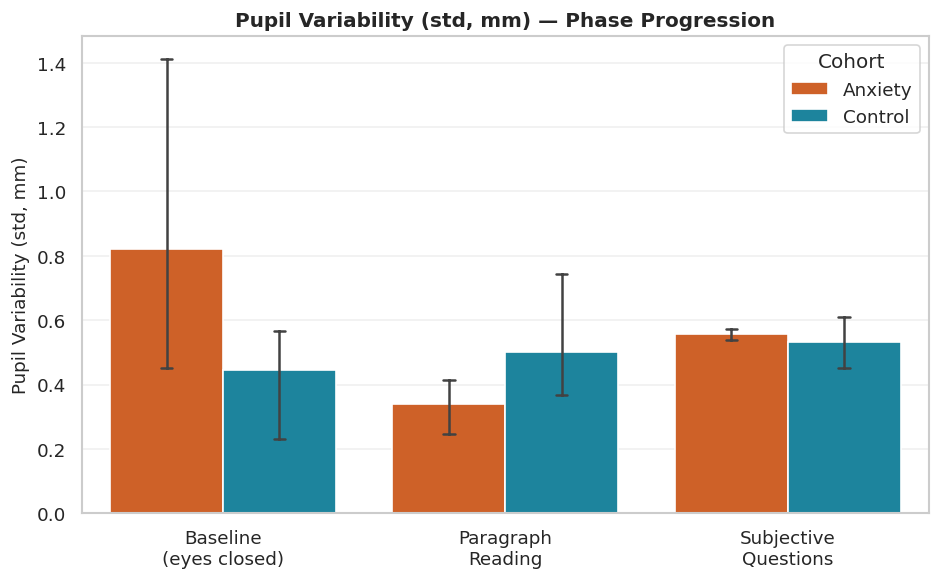

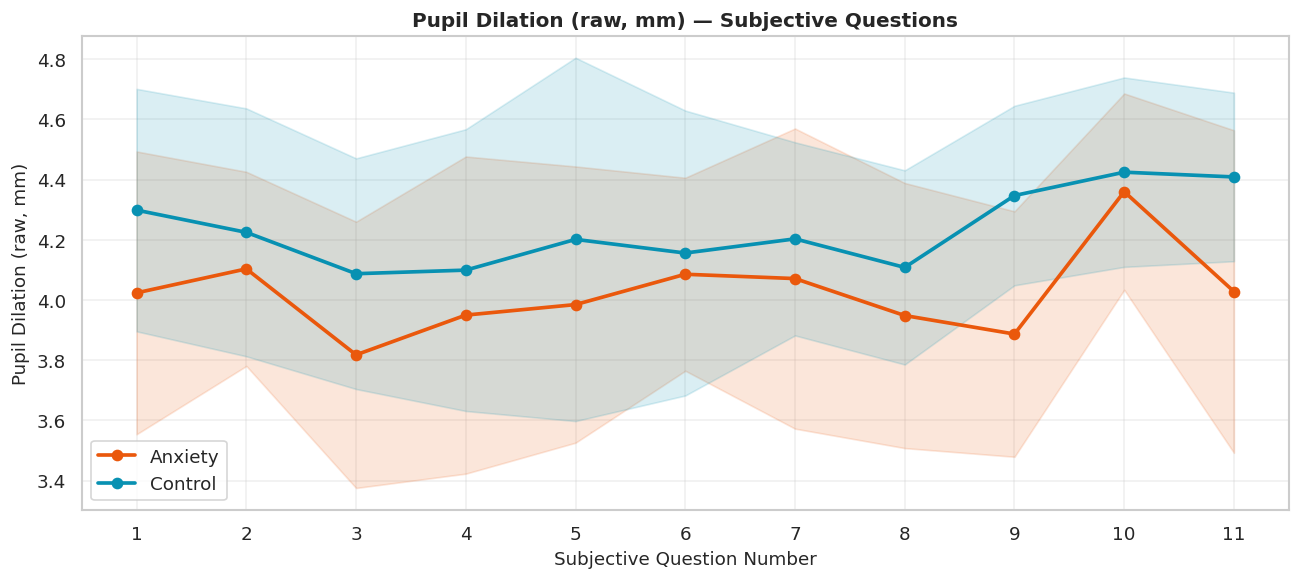

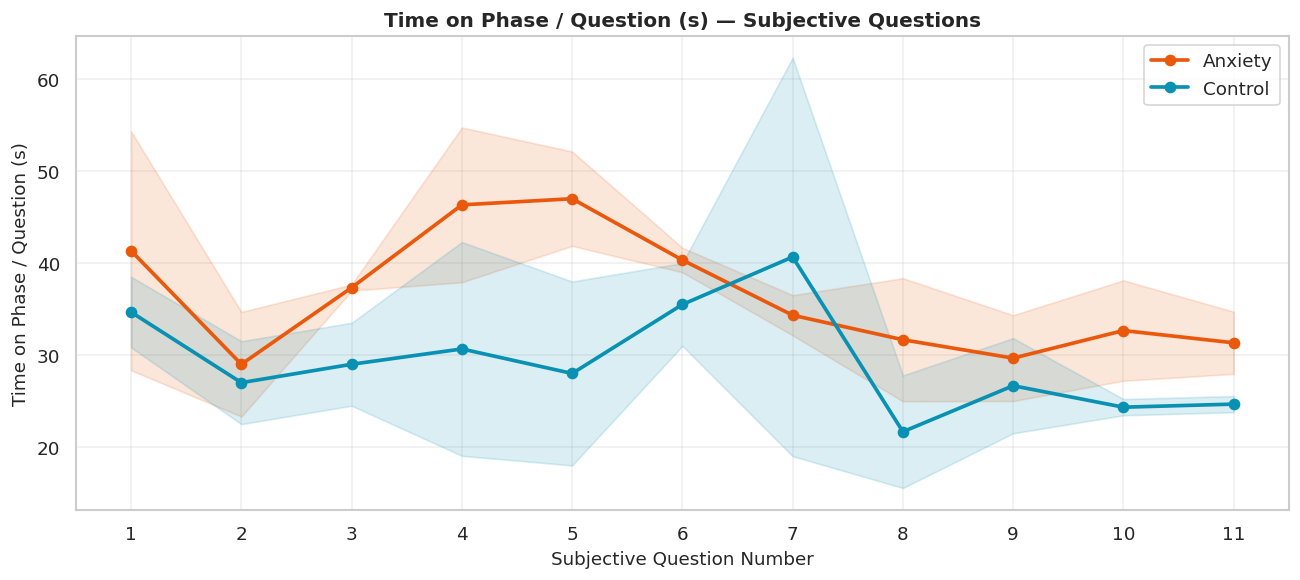

In [36]:
plot_preMCQ_phases(df_preMCQ, feat='pupil_mean')
plot_preMCQ_phases(df_preMCQ, feat='pupil_mean_ec_bc')
plot_preMCQ_phases(df_preMCQ, feat='blink_count')
plot_preMCQ_phases(df_preMCQ, feat='gaze_y_std')

plot_preMCQ_progression(df_preMCQ, feat='pupil_mean')
plot_preMCQ_progression(df_preMCQ, feat='pupil_std')

plot_subjective_questions(df_preMCQ, feat='pupil_mean')
plot_subjective_questions(df_preMCQ, feat='response_time')


### Cell I · Export Pre-MCQ Results

In [37]:
df_preMCQ.to_csv(OUTPUT_DIR/'preMCQ_features.csv', index=False)

preMCQ_cols = [c for c in PREMCQ_FEATURES if c in df_preMCQ.columns]
preMCQ_summary = df_preMCQ.groupby(['group','phase'])[preMCQ_cols].agg(['mean','std','count'])
preMCQ_summary.columns = ['_'.join(c) for c in preMCQ_summary.columns]
preMCQ_summary = preMCQ_summary.reset_index()
display(preMCQ_summary)
preMCQ_summary.to_csv(OUTPUT_DIR/'preMCQ_summary.csv', index=False)

print('\n✅ Pre-MCQ outputs saved to:', OUTPUT_DIR)
print('   ├── preMCQ_features.csv')
print('   ├── preMCQ_summary.csv')
print('   ├── stats_preMCQ_groups.csv')
print('   ├── stats_preMCQ_progression.csv')
print('   ├── stats_preMCQ_subjective_questions.csv')
print('   ├── preMCQ_phases_pupil_mean.png')
print('   ├── preMCQ_phases_pupil_mean_ec_bc.png')
print('   ├── preMCQ_phases_blink_count.png')
print('   ├── preMCQ_phases_gaze_y_std.png')
print('   ├── preMCQ_progression_pupil_mean.png')
print('   ├── preMCQ_progression_pupil_std.png')
print('   ├── preMCQ_subjQ_pupil_mean.png')
print('   └── preMCQ_subjQ_response_time.png')


,group,phase,pupil_mean_mean,pupil_mean_std,pupil_mean_count,pupil_mean_ec_bc_mean,pupil_mean_ec_bc_std,pupil_mean_ec_bc_count,pupil_std_mean,pupil_std_std,...,blink_dur_mean_count,gaze_x_std_mean,gaze_x_std_std,gaze_x_std_count,gaze_y_std_mean,gaze_y_std_std,gaze_y_std_count,response_time_mean,response_time_std,response_time_count
0,anxiety,baseline,4.381012,0.454863,3,0.000000,0.000000,3,0.822115,0.516271,...,0,NaN,NaN,0,NaN,NaN,0,180.333333,0.577350,3
1,anxiety,reading,3.128571,0.376947,3,-1.252440,0.281965,3,0.339768,0.085534,...,0,0.082379,0.004713,3,0.127540,0.017163,3,67.666667,3.214550,3
2,anxiety,subjective,4.044179,0.721735,3,-0.336832,0.764937,3,0.556355,0.016348,...,0,0.132794,0.049583,3,0.215643,0.064505,3,401.000000,25.709920,3
3,anxiety,subjective_q,4.023603,0.644489,33,-0.357409,0.667779,33,0.510603,0.097745,...,0,0.106494,0.045335,33,0.175438,0.082304,33,36.454545,10.796675,33
4,control,baseline,4.393659,0.856210,3,0.000000,0.000000,3,0.445745,0.186650,...,0,NaN,NaN,0,NaN,NaN,0,180.666667,1.154701,3
5,control,reading,3.639171,0.941274,3,-0.754488,0.085889,3,0.501278,0.211098,...,0,0.082720,0.003970,3,0.150637,0.051479,3,64.000000,9.643651,3
6,control,subjective,4.261694,0.576339,3,-0.131966,0.654931,3,0.532717,0.079342,...,0,0.096921,0.029211,3,0.110484,0.028642,3,301.666667,21.031722,3
7,control,subjective_q,4.236232,0.536884,31,-0.098742,0.546900,31,0.494734,0.141669,...,0,0.084831,0.036818,31,0.095592,0.054485,31,29.193548,13.546019,31



✅ Pre-MCQ outputs saved to: /content/drive/MyDrive/eyetracking/gaze_analysis_output_results
   ├── preMCQ_features.csv
   ├── preMCQ_summary.csv
   ├── stats_preMCQ_groups.csv
   ├── stats_preMCQ_progression.csv
   ├── stats_preMCQ_subjective_questions.csv
   ├── preMCQ_phases_pupil_mean.png
   ├── preMCQ_phases_pupil_mean_ec_bc.png
   ├── preMCQ_phases_blink_count.png
   ├── preMCQ_phases_gaze_y_std.png
   ├── preMCQ_progression_pupil_mean.png
   ├── preMCQ_progression_pupil_std.png
   ├── preMCQ_subjQ_pupil_mean.png
   └── preMCQ_subjQ_response_time.png
